# TCL Pipeline New 5 (Approach 5 Logic, Approach 4 Structure)

This notebook keeps the full **Approach 5** logic and parameters from `TCL_Pipeline_5.ipynb`, but follows the section organization style used in `TCL_Pipeline_4.ipynb`.

## 1. Imports

In [1]:
# Install required packages
!pip install -q sentence-transformers transformers spacy scikit-learn ruptures
!python -m spacy download en_core_web_sm

print("✅ Packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 871.5 kB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✅ Packages installed


In [2]:
# Core imports
import os
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter
import copy


# Data processing
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ML/DL
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

# NLP
import spacy
from sentence_transformers import SentenceTransformer

# Segmentation
import ruptures as rpt

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ Imports loaded")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/home/hp/SEM2/INLP/Naretve_Shift/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce MX450
GPU Memory: 1.76 GB


## 2. Config

Approach-5 parameters are preserved exactly; only section layout follows Approach-4 style.

In [3]:
class Config:
    """Central configuration grouped by functionality (AP4-style organization)."""

    # 0) Alignment profile
    ALIGNMENT_SETTINGS = {
        'match_ap4_structure': True,
    }

    # 1) Paths and I/O
    PATH_SETTINGS = {
        'data_dir': '/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Distributed_Data/BAL_TOPIC_WISE_W5',
        'output_dir': './tcl_output_new_5',
    }

    # 2) Topics and source files
    TOPIC_DATA_SETTINGS = {
        'topics': ['Health', 'War', 'Technology', 'Climate', 'Economics'],
        'embedding_column': 'w5_embedding',
        'topic_weight_threshold': 0.0,
    }

    # 3) Feature construction
    FEATURE_SETTINGS = {
        'embedding_dim': 768,
        'entity_proj_dim': 64,
        'topic_emb_dim': 64,
        'window_size': 3,
        'window_stride': 1,
        'ner_batch_size': 256,
        'aggregation_method': 'weighted_mean',
    }

    # 4) Grouping strategy
    GROUPING_SETTINGS = {
        'use_ruptures': True,
        'rupture_model': 'rbf',
        'rupture_pen': 1,
        'min_group_size': 5,
    }

    # 5) Model architecture
    MODEL_SETTINGS = {
        'hidden_dim': 512,
        'num_heads': 8,
        'num_layers': 4,
        'dropout': 0.1,
        'output_dim': 256,
    }

    # 6) Loss and objective
    LOSS_SETTINGS = {
        'lambda_temporal': 1.5,
        'lambda_topic_sep': 0.2,
        'lambda_hard_neg': 0.3,
        'lambda_entity': 0.5,
        'entity_margin': 0.3,
        'temperature': 0.05,
        'entity_lambda': 0.3,
        'use_projection': False,
        'entity_overlap_threshold': 0.3,
        'shift_threshold': 0.5,
    }

    # 7) Training and optimization
    TRAINING_SETTINGS = {
        'batch_size': 16,
        'num_epochs': 100,
        'learning_rate': 1e-4,
        'weight_decay': 1e-5,
        'grad_clip': 1.0,
        'use_amp': True,
        'use_cosine_schedule': True,
        'warmup_epochs': 5,
        'save_every': 5,
    }

    # 8) Artifact naming
    ARTIFACT_SETTINGS = {
        'approach_id': '5',
        'model_name_prefix': 'approch',
        'model_type': 'entity_tcl',
        'model_name_template': '{model_name_prefix}_{model_type}_{model_group_size}_{approach_id}_w{window_size}_s{stride}_t{temperature_tag}',
        'load_variant': 'best',
    }

    @staticmethod
    def _temperature_tag(value):
        return str(value).replace('.', 'p')

    def __init__(self):
        # Merge grouped settings first
        merged = {}
        for group in [
            self.ALIGNMENT_SETTINGS,
            self.PATH_SETTINGS,
            self.TOPIC_DATA_SETTINGS,
            self.FEATURE_SETTINGS,
            self.GROUPING_SETTINGS,
            self.MODEL_SETTINGS,
            self.LOSS_SETTINGS,
            self.TRAINING_SETTINGS,
            self.ARTIFACT_SETTINGS,
        ]:
            merged.update(group)

        # Canonical attributes used by Approach-5 code (kept for compatibility)
        self.DATA_DIR = Path(merged['data_dir'])
        self.OUTPUT_DIR = Path(merged['output_dir'])
        self.CHECKPOINT_DIR = self.OUTPUT_DIR

        self.TOPICS = merged['topics']
        self.TOPIC_FILES = {topic: f'{topic}.csv' for topic in self.TOPICS}
        self.EMBEDDING_COLUMN = merged['embedding_column']
        self.TOPIC_WEIGHT_THRESHOLD = float(merged['topic_weight_threshold'])

        self.APPROACH_ID = merged['approach_id']
        self.MODEL_NAME_PREFIX = merged['model_name_prefix']
        self.MODEL_TYPE = merged['model_type']
        self.MODEL_NAME_TEMPLATE = merged['model_name_template']
        self.LOAD_VARIANT = merged['load_variant']

        self.ENTITY_LAMBDA = float(merged['entity_lambda'])
        self.USE_PROJECTION = bool(merged['use_projection'])
        self.ENTITY_PROJ_DIM = int(merged['entity_proj_dim'])

        self.SBERT_MODEL = 'all-mpnet-base-v2'
        self.EMBEDDING_DIM = int(merged['embedding_dim'])
        self.SENTENCE_FINAL_DIM = self.EMBEDDING_DIM + self.ENTITY_PROJ_DIM
        self.TOPIC_EMB_DIM = int(merged['topic_emb_dim'])
        self.CONCAT_DIM = self.SENTENCE_FINAL_DIM + self.TOPIC_EMB_DIM

        self.NER_BATCH_SIZE = int(merged['ner_batch_size'])
        self.AGGREGATION_METHOD = merged['aggregation_method']

        self.USE_RUPTURES = bool(merged['use_ruptures'])
        self.RUPTURE_MODEL = merged['rupture_model']
        self.RUPTURE_PEN = merged['rupture_pen']
        self.MIN_GROUP_SIZE = int(merged['min_group_size'])

        self.WINDOW_SIZE = int(merged['window_size'])
        self.WINDOW_STRIDE = int(merged['window_stride'])

        self.HIDDEN_DIM = int(merged['hidden_dim'])
        self.NUM_HEADS = int(merged['num_heads'])
        self.NUM_LAYERS = int(merged['num_layers'])
        self.DROPOUT = float(merged['dropout'])
        self.OUTPUT_DIM = int(merged['output_dim'])

        self.LAMBDA_TEMPORAL = float(merged['lambda_temporal'])
        self.LAMBDA_TOPIC_SEP = float(merged['lambda_topic_sep'])
        self.LAMBDA_HARD_NEG = float(merged['lambda_hard_neg'])
        self.LAMBDA_ENTITY = float(merged['lambda_entity'])
        self.ENTITY_MARGIN = float(merged['entity_margin'])
        self.TEMPERATURE = float(merged['temperature'])
        self.SHIFT_THRESHOLD = float(merged['shift_threshold'])
        self.ENTITY_OVERLAP_THRESHOLD = float(merged['entity_overlap_threshold'])

        self.BATCH_SIZE = int(merged['batch_size'])
        self.NUM_EPOCHS = int(merged['num_epochs'])
        self.LEARNING_RATE = float(merged['learning_rate'])
        self.WEIGHT_DECAY = float(merged['weight_decay'])
        self.GRAD_CLIP = float(merged['grad_clip'])
        self.USE_AMP = bool(merged['use_amp'])
        self.USE_COSINE_SCHEDULE = bool(merged['use_cosine_schedule'])
        self.WARMUP_EPOCHS = int(merged['warmup_epochs'])
        self.SAVE_EVERY = int(merged['save_every'])

        self.DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        model_group_size = f"pen{str(self.RUPTURE_PEN).replace('.', 'p')}"
        self.MODEL_BASE_NAME = self.MODEL_NAME_TEMPLATE.format(
            model_name_prefix=self.MODEL_NAME_PREFIX,
            model_type=self.MODEL_TYPE,
            model_group_size=model_group_size,
            approach_id=self.APPROACH_ID,
            window_size=self.WINDOW_SIZE,
            stride=self.WINDOW_STRIDE,
            temperature_tag=self._temperature_tag(self.TEMPERATURE),
        )

        self.MODEL_BEST_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_best.pt'
        self.MODEL_LAST_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_last.pt'
        self.MODEL_EVALUATED_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_evaluated.pt'
        self.TRAINING_HISTORY_PLOT_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_train_loss.png'
        self.RUN_SUMMARY_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_run_summary.json'
        self.EVAL_METRICS_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_evaluation_metrics.json'
        self.INFERENCE_OUTPUT_DIR = self.OUTPUT_DIR
        self.INFERENCE_RESULTS_PATH = self.OUTPUT_DIR / f'{self.MODEL_BASE_NAME}_user_inference_multi_topic.json'


config = Config()

print('=' * 80)
print('CONFIGURATION LOADED (GROUPED BY FUNCTIONALITY)')
print('=' * 80)
print(f'Device: {config.DEVICE}')
print(f'Topics: {config.TOPICS}')
print(f'Embedding source column: {config.EMBEDDING_COLUMN}')
print(f'Embedding: {config.SBERT_MODEL} ({config.EMBEDDING_DIM}D)')
print(f'Entity projection: {config.ENTITY_PROJ_DIM}D')
print(f'Sentence final dim: {config.SENTENCE_FINAL_DIM}D')
print(f'Topic embedding: {config.TOPIC_EMB_DIM}D')
print(f'Concatenated input: {config.CONCAT_DIM}D')
print(f'Model output: {config.OUTPUT_DIM}D')
print(f'Window size: {config.WINDOW_SIZE}')
print(f'Batch size: {config.BATCH_SIZE}')
print(f'Epochs: {config.NUM_EPOCHS}')
print(f'Output folder: {config.OUTPUT_DIR}')
print(f'Model base name: {config.MODEL_BASE_NAME}')
print(f'Best model path: {config.MODEL_BEST_PATH}')
print(f'Last model path: {config.MODEL_LAST_PATH}')
print(f'Inference result path: {config.INFERENCE_RESULTS_PATH}')
print('=' * 80)

CONFIGURATION LOADED (GROUPED BY FUNCTIONALITY)
Device: cuda
Topics: ['Health', 'War', 'Technology', 'Climate', 'Economics']
Embedding source column: w5_embedding
Embedding: all-mpnet-base-v2 (768D)
Entity projection: 64D
Sentence final dim: 832D
Topic embedding: 64D
Concatenated input: 896D
Model output: 256D
Window size: 3
Batch size: 16
Epochs: 100
Output folder: tcl_output_new_5
Model base name: approch_entity_tcl_pen1_5_w3_s1_t0p05
Best model path: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_best.pt
Last model path: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_last.pt
Inference result path: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_user_inference_multi_topic.json


## 3. Data Loading and Preprocessing Functions

## 3.1: Loader Setup

## 3.2: Load CSV Data

In [4]:
def load_topic_csv(topic, data_dir):
    """
    Load CSV for a specific topic with AP4-style column normalization.

    Behavior:
    - Use config.EMBEDDING_COLUMN first
    - If missing, fall back to embedding/w5_embedding/w3_embedding
    - Support embeddings already in array/list form
    - Parse string embeddings only when required
    """
    topic_file = config.TOPIC_FILES.get(topic, f"{topic}.csv")
    csv_path = data_dir / topic_file

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    print(f"Loading {topic} data from {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"  Loaded {len(df):,} rows")
    print(f"  Columns: {list(df.columns)}")

    # AP4-like robust date parsing
    df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

    # Resolve embedding source column using AP4-like fallback order
    candidate_cols = [config.EMBEDDING_COLUMN, 'embedding', 'w5_embedding', 'w3_embedding']
    embedding_col = next((c for c in candidate_cols if c in df.columns), None)
    if embedding_col is None:
        raise ValueError(f"No embedding column found! Available columns: {list(df.columns)}")

    series = df[embedding_col]
    first_non_null = next((v for v in series.values if pd.notna(v)), None)
    embedding_already_array = isinstance(first_non_null, (np.ndarray, list, tuple))

    if embedding_already_array:
        print(f"  Embeddings already array-like in '{embedding_col}', using direct conversion")
        df['embedding'] = series.apply(lambda x: np.asarray(x, dtype=np.float32))
    else:
        if embedding_col != 'embedding':
            print(f"  Using '{embedding_col}' as embedding source")
        print("  Parsing string embeddings -> float32 arrays")

        def _parse_inline(value):
            if isinstance(value, np.ndarray):
                return value.astype(np.float32)
            if isinstance(value, list):
                return np.asarray(value, dtype=np.float32)
            if isinstance(value, str):
                cleaned = value.strip("[]\"'").replace('\n', ' ').replace('\r', ' ')
                if ',' in cleaned:
                    cleaned = cleaned.replace(',', ' ')
                parsed = np.fromstring(cleaned, sep=' ', dtype=np.float32)
                if parsed.size > 0:
                    return parsed
                import ast
                return np.asarray(ast.literal_eval(value), dtype=np.float32)
            return np.asarray(value, dtype=np.float32)

        df['embedding'] = series.apply(_parse_inline)

    # Validate embedding size to match model expectation
    valid_mask = df['embedding'].apply(lambda x: len(x) == config.EMBEDDING_DIM)
    before_valid = len(df)
    df = df[valid_mask].reset_index(drop=True)
    if len(df) != before_valid:
        print(f"  Dropped {before_valid - len(df)} rows with invalid embedding size")

    # Normalize topic score column naming: `{topic}_weight` -> `{topic}`
    topic_weight_alt = f"{topic}_weight"
    if topic not in df.columns and topic_weight_alt in df.columns:
        df[topic] = df[topic_weight_alt].astype(np.float32)
    if topic in df.columns:
        df[topic] = pd.to_numeric(df[topic], errors='coerce').fillna(0.0).astype(np.float32)

    # Keep AP4-style threshold option available without forcing behavior
    if topic in df.columns and float(config.TOPIC_WEIGHT_THRESHOLD) > 0.0:
        before_th = len(df)
        df = df[df[topic] >= float(config.TOPIC_WEIGHT_THRESHOLD)].reset_index(drop=True)
        print(f"  Threshold filter >= {config.TOPIC_WEIGHT_THRESHOLD:.2f}: {before_th} -> {len(df)}")

    # Normalize sentence text column
    if 'main_sentence' not in df.columns:
        for fallback_col in ['sentence', 'article', 'content', 'window_text']:
            if fallback_col in df.columns:
                df['main_sentence'] = df[fallback_col].astype(str)
                break
        if 'main_sentence' not in df.columns:
            df['main_sentence'] = ''

    # Normalize sentence id column
    if 'sentence_id' not in df.columns:
        df['sentence_id'] = [f"{topic}_s{i}" for i in range(len(df))]

    print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"  ✅ {topic} data loaded")

    return df


print("✅ CSV loading function defined")

# Load all topic CSV files immediately after function definition
topic_loaded_data = {}
print("\n" + "=" * 80)
print("LOAD ALL TOPIC FILES (EARLY LOAD)")
print("=" * 80)
for topic_name in config.TOPICS:
    try:
        topic_loaded_data[topic_name] = load_topic_csv(topic_name, config.DATA_DIR)
        print(f"  {topic_name}: {len(topic_loaded_data[topic_name]):,} rows")
    except Exception as exc:
        print(f"  {topic_name}: failed -> {exc}")
print("=" * 80)
print(f"Loaded topics now: {list(topic_loaded_data.keys())}")

✅ CSV loading function defined

LOAD ALL TOPIC FILES (EARLY LOAD)
Loading Health data from /home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Distributed_Data/BAL_TOPIC_WISE_W5/Health.csv...
  Loaded 17,323 rows
  Columns: ['date', 'sentence_id', 'main_sentence', 'w5_embedding', 'War', 'Health', 'Technology', 'Climate', 'Economics', 'max_topic_weight', 'second_topic_weight', 'topic_gap', 'dominant_topic', 'year', 'month', 'year_month']
  Using 'w5_embedding' as embedding source
  Parsing string embeddings -> float32 arrays
  Date range: 2011-10-17 21:41:17 to 2025-10-26 06:13:41
  ✅ Health data loaded
  Health: 17,323 rows
Loading War data from /home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Distributed_Data/BAL_TOPIC_WISE_W5/War.csv...
  Loaded 34,841 rows
  Columns: ['date', 'sentence_id', 'main_sentence', 'w5_embedding', 'War', 'Health', 'Technology', 'Climate', 'Economics', 'max_topic_weight', 'second_topic_weight', 'topic_gap', 'dominant_topic', 'year', 'month', 'year_month']
  Using

## 3.3: Named Entity Recognition

In [5]:
# Load spaCy model
print("Loading spaCy NER model...")
nlp = spacy.load('en_core_web_sm', disable=['parser', 'tagger', 'lemmatizer'])
if 'sentencizer' not in nlp.pipe_names and 'senter' not in nlp.pipe_names and 'parser' not in nlp.pipe_names:
    nlp.add_pipe('sentencizer')
print(f"✅ spaCy model loaded | pipeline: {nlp.pipe_names}")

Loading spaCy NER model...
✅ spaCy model loaded | pipeline: ['tok2vec', 'attribute_ruler', 'ner', 'sentencizer']


In [6]:
def extract_entities_batch(df, batch_size=256):
    """
    Extract named entities from sentences using spaCy.

    Returns:
        df with columns: entities, entity_signature
    """
    print(f"Extracting entities (batch_size={batch_size})...")

    sentences = df['main_sentence'].tolist()
    all_entities = []
    entity_signatures = []

    for i in tqdm(range(0, len(sentences), batch_size), desc="NER"):
        batch_sentences = sentences[i:i + batch_size]
        docs = list(nlp.pipe(batch_sentences, batch_size=batch_size))

        for doc in docs:
            entities = [ent.text.strip() for ent in doc.ents if ent.text and ent.text.strip()]
            all_entities.append(entities)

            if entities:
                normalized = sorted({e.lower() for e in entities})
                entity_signatures.append(" | ".join(normalized[:5]))
            else:
                entity_signatures.append("__NO_ENTITY__")

    df['entities'] = all_entities
    df['entity_signature'] = entity_signatures

    num_with_entities = sum(1 for e in all_entities if len(e) > 0)
    total_entities = sum(len(e) for e in all_entities)

    print("Entity extraction complete")
    print(f"  Sentences with entities: {num_with_entities}/{len(df)} ({num_with_entities / max(len(df), 1) * 100:.1f}%)")
    print(f"  Total entities: {total_entities:,}")
    print(f"  Avg entities/sentence: {total_entities / max(len(df), 1):.2f}")

    return df


print("✅ NER function defined")

# Run NER immediately on already-loaded topic CSV data (one topic at a time).
if 'topic_loaded_data' not in globals() or not topic_loaded_data:
    raise RuntimeError("topic_loaded_data is empty. Run the CSV loading cell first.")

print("\n" + "=" * 80)
print("RUN NER ON LOADED TOPIC FILES (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_loaded_data:
        print(f"  {topic_name}: skipped (not loaded)")
        continue

    topic_df = topic_loaded_data[topic_name].copy()

    # Keep embedding column in consistent ndarray float32 format.
    if 'embedding' in topic_df.columns:
        topic_df['embedding'] = topic_df['embedding'].apply(lambda x: np.asarray(x, dtype=np.float32))

    topic_df = extract_entities_batch(topic_df, batch_size=config.NER_BATCH_SIZE)
    topic_loaded_data[topic_name] = topic_df

    print(f"  {topic_name}: updated with NER | rows={len(topic_df):,}")

print("=" * 80)
print("NER update complete for loaded topics")

✅ NER function defined

RUN NER ON LOADED TOPIC FILES (ONE BY ONE)
Extracting entities (batch_size=256)...


NER: 100%|██████████| 68/68 [00:43<00:00,  1.55it/s]


Entity extraction complete
  Sentences with entities: 11910/17323 (68.8%)
  Total entities: 38,991
  Avg entities/sentence: 2.25
  Health: updated with NER | rows=17,323
Extracting entities (batch_size=256)...


NER: 100%|██████████| 137/137 [01:53<00:00,  1.21it/s]


Entity extraction complete
  Sentences with entities: 29973/34841 (86.0%)
  Total entities: 182,789
  Avg entities/sentence: 5.25
  War: updated with NER | rows=34,841
Extracting entities (batch_size=256)...


...

Entity extraction complete
  Sentences with entities: 6381/9592 (66.5%)
  Total entities: 17,639
  Avg entities/sentence: 1.84
  Technology: updated with NER | rows=9,592
Extracting entities (batch_size=256)...


NER: 100%|██████████| 63/63 [00:39<00:00,  1.60it/s]


Entity extraction complete
  Sentences with entities: 11202/16117 (69.5%)
  Total entities: 36,296
  Avg entities/sentence: 2.25
  Climate: updated with NER | rows=16,117
Extracting entities (batch_size=256)...


NER: 100%|██████████| 17/17 [00:09<00:00,  1.75it/s]

Entity extraction complete
  Sentences with entities: 2941/4145 (71.0%)
  Total entities: 10,039
  Avg entities/sentence: 2.42
  Economics: updated with NER | rows=4,145
NER update complete for loaded topics


## 3.4: Entity Embeddings

In [7]:
def compute_entity_embeddings(df, sbert_model):
    """
    Compute entity embeddings by encoding entity text.

    Returns:
        df with 'entity_embedding' (768D, normalized)
    """
    print("Computing entity embeddings...")

    entity_embeddings = []
    embedding_dim = config.EMBEDDING_DIM

    for entities in tqdm(df['entities'], desc="Entity embeddings"):
        if len(entities) == 0:
            entity_embedding = np.zeros(embedding_dim, dtype=np.float32)
        else:
            entity_text = " ".join(entities)
            entity_embedding = sbert_model.encode(entity_text, convert_to_numpy=True).astype(np.float32)

        norm = np.linalg.norm(entity_embedding)
        if norm > 1e-6:
            entity_embedding = entity_embedding / norm

        entity_embeddings.append(entity_embedding.astype(np.float32))

    df['entity_embedding'] = entity_embeddings

    print("Entity embeddings computed")
    return df


print("✅ Entity embedding function defined")

# Run entity embeddings immediately on loaded topic data (one topic at a time).
if 'topic_loaded_data' not in globals() or not topic_loaded_data:
    raise RuntimeError("topic_loaded_data is empty. Run CSV loading + NER cells first.")

# Section 2.4 can run before later stage cells, so initialize SBERT here if missing.
if 'sbert_model' not in globals():
    print(f"Loading SBERT model for Section 2.4: {config.SBERT_MODEL}")
    preferred_device = 'cuda' if torch.cuda.is_available() else 'cpu'
    sbert_device = preferred_device
    try:
        sbert_model = SentenceTransformer(config.SBERT_MODEL, device=preferred_device)
    except RuntimeError as exc:
        err = str(exc).lower()
        if preferred_device == 'cuda' and ('outofmemory' in err or 'cuda out of memory' in err):
            print("CUDA OOM for SBERT in Section 2.4. Falling back to CPU.")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            sbert_device = 'cpu'
            sbert_model = SentenceTransformer(config.SBERT_MODEL, device='cpu')
        else:
            raise
else:
    sbert_device = 'cuda' if config.DEVICE.type == 'cuda' else 'cpu'

print(f"SBERT device for Section 2.4: {sbert_device}")

print("\n" + "=" * 80)
print("RUN ENTITY EMBEDDINGS ON LOADED TOPIC FILES (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_loaded_data:
        print(f"  {topic_name}: skipped (not loaded)")
        continue

    topic_df = topic_loaded_data[topic_name].copy()

    if 'entities' not in topic_df.columns:
        print(f"  {topic_name}: skipped (entities column missing, run NER first)")
        continue

    topic_df = compute_entity_embeddings(topic_df, sbert_model)
    topic_loaded_data[topic_name] = topic_df

    print(f"  {topic_name}: entity embeddings updated | rows={len(topic_df):,}")

print("=" * 80)
print("Entity embedding update complete for loaded topics")

✅ Entity embedding function defined
Loading SBERT model for Section 2.4: all-mpnet-base-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 822.89it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT device for Section 2.4: cuda

RUN ENTITY EMBEDDINGS ON LOADED TOPIC FILES (ONE BY ONE)
Computing entity embeddings...


Entity embeddings: 100%|██████████| 17323/17323 [03:28<00:00, 83.11it/s] 


Entity embeddings computed
  Health: entity embeddings updated | rows=17,323
Computing entity embeddings...


...

Entity embeddings computed
  Technology: entity embeddings updated | rows=9,592
Computing entity embeddings...


Entity embeddings: 100%|██████████| 16117/16117 [03:06<00:00, 86.41it/s] 


Entity embeddings computed
  Climate: entity embeddings updated | rows=16,117
Computing entity embeddings...


Entity embeddings: 100%|██████████| 4145/4145 [00:45<00:00, 91.72it/s] 

Entity embeddings computed
  Economics: entity embeddings updated | rows=4,145
Entity embedding update complete for loaded topics


## 3.5: Entity-Invariant Cleaning

In [8]:
def compute_entity_invariant_embeddings(df, entity_proj_layer, device, method='subtraction', lambda_=0.3):
    """
    Compute dual entity-aware sentence representation.

    Implemented rule (fixed):
      E_sem_clean = E_sem - lambda * E_ent
      E_ent_small = Linear(E_ent) -> 64D
      E_final     = concat(E_sem_clean(768), E_ent_small(64)) = 832

    Note: `method` is kept in signature for backward compatibility,
    but this implementation always uses the formula above.

    Returns:
        df with columns: semantic_clean_embedding, entity_small_embedding, final_embedding
    """
    print(f"Computing entity-aware dual embeddings (fixed formula, lambda={lambda_})...")

    semantic_clean_embeddings = []
    entity_small_embeddings = []
    final_embeddings = []

    entity_proj_layer.eval()
    proj_device = next(entity_proj_layer.parameters()).device

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Entity-aware representation"):
        sem_emb = np.asarray(row['embedding'], dtype=np.float32)
        ent_emb = np.asarray(row['entity_embedding'], dtype=np.float32)

        sem_clean = sem_emb - float(lambda_) * ent_emb

        sem_norm = np.linalg.norm(sem_clean)
        if sem_norm > 1e-6:
            sem_clean = sem_clean / sem_norm

        with torch.no_grad():
            ent_tensor = torch.from_numpy(ent_emb).to(device=proj_device, dtype=torch.float32).unsqueeze(0)
            ent_small = entity_proj_layer(ent_tensor).squeeze(0).cpu().numpy().astype(np.float32)

        ent_small_norm = np.linalg.norm(ent_small)
        if ent_small_norm > 1e-6:
            ent_small = ent_small / ent_small_norm

        final_emb = np.concatenate([sem_clean.astype(np.float32), ent_small], axis=0).astype(np.float32)

        semantic_clean_embeddings.append(sem_clean.astype(np.float32))
        entity_small_embeddings.append(ent_small.astype(np.float32))
        final_embeddings.append(final_emb)

    df['semantic_clean_embedding'] = semantic_clean_embeddings
    df['entity_small_embedding'] = entity_small_embeddings
    df['final_embedding'] = final_embeddings

    print(f"Entity-aware representation ready: {config.EMBEDDING_DIM} + {config.ENTITY_PROJ_DIM} = {config.SENTENCE_FINAL_DIM}")
    return df


print("✅ Entity-aware dual representation function defined")

# Cache setup for section 3.5
BASE_PROCESSED_DIR = Path("Processed_Data")
BASE_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ENTITY_INVARIANT_CACHE_DIR = BASE_PROCESSED_DIR / "Stage_3_5_Entity_Invariant"
ENTITY_INVARIANT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
ALLOWED_NEW_35_COLUMNS = {"semantic_clean_embedding", "entity_small_embedding", "final_embedding"}


def _entity_cache_path_35(topic_name):
    safe_name = str(topic_name).strip().replace("/", "_").replace(" ", "_")
    return ENTITY_INVARIANT_CACHE_DIR / f"{safe_name}_entity_invariant.pkl"


def _is_cache_35_compatible(current_df, cached_df):
    if cached_df is None or len(cached_df) == 0:
        return False, "cached df empty"

    missing_new_cols = [c for c in ALLOWED_NEW_35_COLUMNS if c not in cached_df.columns]
    if missing_new_cols:
        return False, f"cached df missing 3.5 cols: {missing_new_cols}"

    current_base_cols = [c for c in current_df.columns if c not in ALLOWED_NEW_35_COLUMNS]
    cached_base_cols = [c for c in cached_df.columns if c not in ALLOWED_NEW_35_COLUMNS]

    if current_base_cols != cached_base_cols:
        return False, "base columns mismatch"

    return True, "ok"


# Run Section 3.5 on loaded topic data, but load cache and skip compute when compatible.
if 'topic_loaded_data' not in globals() or not topic_loaded_data:
    raise RuntimeError("topic_loaded_data is empty. Run CSV loading + NER + 2.4 cells first.")

# Section 3.5 can run before later stage cells, so initialize entity_proj_layer if missing.
if 'entity_proj_layer' not in globals():
    print("Initializing entity projection layer for Section 2.5")
    entity_proj_layer = nn.Linear(config.EMBEDDING_DIM, config.ENTITY_PROJ_DIM).to(config.DEVICE)
    nn.init.xavier_uniform_(entity_proj_layer.weight)
    nn.init.zeros_(entity_proj_layer.bias)

# Probe projection device; fallback to CPU if CUDA projection fails.
entity_proj_device = config.DEVICE
if str(entity_proj_device).startswith('cuda'):
    try:
        with torch.no_grad():
            _probe = torch.zeros((1, config.EMBEDDING_DIM), dtype=torch.float32, device=entity_proj_device)
            _ = entity_proj_layer(_probe)
    except RuntimeError as exc:
        err = str(exc).lower()
        if 'cublas' in err or 'cuda' in err or 'out of memory' in err:
            print("CUDA projection failed in Section 2.5. Falling back to CPU for entity projection.")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            entity_proj_layer = entity_proj_layer.to('cpu')
            entity_proj_device = torch.device('cpu')
        else:
            raise
else:
    entity_proj_device = torch.device('cpu')

print(f"Entity projection device for Section 2.5: {entity_proj_device}")
print(f"3.5 cache dir: {ENTITY_INVARIANT_CACHE_DIR.resolve()}")

print("\n" + "=" * 80)
print("RUN ENTITY-INVARIANT CLEANING ON LOADED TOPIC FILES (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_loaded_data:
        print(f"  {topic_name}: skipped (not loaded)")
        continue

    topic_df = topic_loaded_data[topic_name].copy()
    cache_file = _entity_cache_path_35(topic_name)

    # 1) Try cache first; if schema matches (only 3.5 cols are new), load and skip compute.
    if cache_file.exists():
        try:
            cached_df = pd.read_pickle(cache_file)
            ok, reason = _is_cache_35_compatible(topic_df, cached_df)
            if ok:
                topic_loaded_data[topic_name] = cached_df
                print(f"  {topic_name}: loaded cache and skipped 3.5 compute | rows={len(cached_df):,}")
                continue
            print(f"  {topic_name}: cache exists but incompatible ({reason}); running compute")
        except Exception as exc:
            print(f"  {topic_name}: cache read failed ({exc}); running compute")

    # 2) Otherwise proceed with current 3.5 computation.
    if 'entity_embedding' not in topic_df.columns:
        print(f"  {topic_name}: skipped (entity_embedding missing, run 2.4 first)")
        continue

    topic_df = compute_entity_invariant_embeddings(
        topic_df,
        entity_proj_layer=entity_proj_layer,
        device=entity_proj_device,
        lambda_=config.ENTITY_LAMBDA,
    )
    topic_loaded_data[topic_name] = topic_df

    # Save for next runs.
    try:
        topic_df.to_pickle(cache_file)
        print(f"  {topic_name}: final_embedding updated + cached | rows={len(topic_df):,}")
    except Exception as exc:
        print(f"  {topic_name}: final_embedding updated (cache save failed: {exc}) | rows={len(topic_df):,}")

print("=" * 80)
print("Section 2.5 update complete for loaded topics")

✅ Entity-aware dual representation function defined
Initializing entity projection layer for Section 2.5
Entity projection device for Section 2.5: cuda
3.5 cache dir: /home/hp/SEM2/INLP/Naretve_Shift/TCL/Processed_Data/Stage_3_5_Entity_Invariant

RUN ENTITY-INVARIANT CLEANING ON LOADED TOPIC FILES (ONE BY ONE)
Computing entity-aware dual embeddings (fixed formula, lambda=0.3)...


Entity-aware representation: 100%|██████████| 17323/17323 [00:03<00:00, 4765.84it/s]


Entity-aware representation ready: 768 + 64 = 832
  Health: final_embedding updated + cached | rows=17,323
Computing entity-aware dual embeddings (fixed formula, lambda=0.3)...


Entity-aware representation: 100%|██████████| 34841/34841 [00:07<00:00, 4440.40it/s]


Entity-aware representation ready: 768 + 64 = 832
  War: final_embedding updated + cached | rows=34,841
Computing entity-aware dual embeddings (fixed formula, lambda=0.3)...


...

Entity-aware representation ready: 768 + 64 = 832
  Technology: final_embedding updated + cached | rows=9,592
Computing entity-aware dual embeddings (fixed formula, lambda=0.3)...


Entity-aware representation: 100%|██████████| 16117/16117 [00:04<00:00, 3504.56it/s]


Entity-aware representation ready: 768 + 64 = 832
  Climate: final_embedding updated + cached | rows=16,117
Computing entity-aware dual embeddings (fixed formula, lambda=0.3)...


Entity-aware representation: 100%|██████████| 4145/4145 [00:01<00:00, 3868.88it/s]


Entity-aware representation ready: 768 + 64 = 832
  Economics: final_embedding updated + cached | rows=4,145
Section 2.5 update complete for loaded topics


In [9]:
# 3.5 cache manager: topic-wise save/load with schema guard.
# Default behavior: if cache exists, load it and do NOT overwrite.
# Optional update mode validates that only 3.5 columns are new.

BASE_PROCESSED_DIR = Path("Processed_Data")
BASE_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ENTITY_INVARIANT_CACHE_DIR = BASE_PROCESSED_DIR / "Stage_3_5_Entity_Invariant"
ENTITY_INVARIANT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

ALLOWED_NEW_35_COLUMNS = {
    "semantic_clean_embedding",
    "entity_small_embedding",
    "final_embedding",
}

UPDATE_EXISTING_ENTITY_CACHE = False  # keep False unless you intentionally want overwrite


def _entity_cache_path(topic_name):
    safe_name = str(topic_name).strip().replace("/", "_").replace(" ", "_")
    return ENTITY_INVARIANT_CACHE_DIR / f"{safe_name}_entity_invariant.pkl"


def _base_columns(df):
    return [col for col in df.columns if col not in ALLOWED_NEW_35_COLUMNS]


print("\n" + "=" * 80)
print("3.5 CACHE: topic-wise save/load with column consistency checks")
print("=" * 80)
print(f"Processed_Data dir: {BASE_PROCESSED_DIR.resolve()}")
print(f"Cache dir: {ENTITY_INVARIANT_CACHE_DIR.resolve()}")
print(f"Update existing cache: {UPDATE_EXISTING_ENTITY_CACHE}")

for topic_name in config.TOPICS:
    if topic_name not in topic_loaded_data:
        print(f"  {topic_name}: skipped (not in topic_loaded_data)")
        continue

    current_df = topic_loaded_data[topic_name].copy()
    cache_file = _entity_cache_path(topic_name)

    if cache_file.exists() and not UPDATE_EXISTING_ENTITY_CACHE:
        cached_df = pd.read_pickle(cache_file)
        topic_loaded_data[topic_name] = cached_df
        print(f"  {topic_name}: loaded cached 3.5 df | rows={len(cached_df):,}")
        continue

    if cache_file.exists() and UPDATE_EXISTING_ENTITY_CACHE:
        cached_df = pd.read_pickle(cache_file)

        current_base = _base_columns(current_df)
        cached_base = _base_columns(cached_df)

        # Guard: all non-3.5 columns should remain identical in name/order.
        if current_base != cached_base:
            print(f"  {topic_name}: cache NOT updated (base columns changed)")
            print(f"    current_base_cols={len(current_base)} | cached_base_cols={len(cached_base)}")
            continue

        current_allowed_present = [c for c in ALLOWED_NEW_35_COLUMNS if c in current_df.columns]
        if len(current_allowed_present) < 3:
            print(f"  {topic_name}: cache NOT updated (missing one or more 3.5 columns)")
            continue

        current_df.to_pickle(cache_file)
        print(f"  {topic_name}: cache updated after schema check | rows={len(current_df):,}")
        continue

    # Cache does not exist: first-time save.
    current_df.to_pickle(cache_file)
    print(f"  {topic_name}: cache created | rows={len(current_df):,}")

print("=" * 80)
print("3.5 cache step complete")


3.5 CACHE: topic-wise save/load with column consistency checks
Processed_Data dir: /home/hp/SEM2/INLP/Naretve_Shift/TCL/Processed_Data
Cache dir: /home/hp/SEM2/INLP/Naretve_Shift/TCL/Processed_Data/Stage_3_5_Entity_Invariant
Update existing cache: False
  Health: loaded cached 3.5 df | rows=17,323
  War: loaded cached 3.5 df | rows=34,841
  Technology: loaded cached 3.5 df | rows=9,592
  Climate: loaded cached 3.5 df | rows=16,117
  Economics: loaded cached 3.5 df | rows=4,145
3.5 cache step complete


## 3.6: Day-Level Aggregation

In [10]:
def aggregate_to_day_level(df, topic):
    """
    Aggregate sentence final embeddings (832D) to day-level using topic weights.

    Args:
        df: DataFrame with 'date', 'final_embedding', topic weight column
        topic: Topic name

    Returns:
        day_df with 832D embedding + entity context
    """
    print(f"Aggregating to day-level for {topic}...")

    weight_col = topic
    if weight_col not in df.columns:
        print(f"  Column '{weight_col}' not found, using uniform weights")
        df[weight_col] = 1.0

    day_records = []

    for date, group in tqdm(df.groupby('date'), desc="Day aggregation"):
        embeddings = np.stack(group['final_embedding'].values).astype(np.float32)
        weights = group[weight_col].astype(np.float32).values

        weighted_sum = (embeddings.T * weights).T.sum(axis=0)
        weight_sum = weights.sum()

        if weight_sum > 0:
            day_embedding = weighted_sum / weight_sum
        else:
            day_embedding = embeddings.mean(axis=0)

        norm = np.linalg.norm(day_embedding)
        if norm > 1e-6:
            day_embedding = day_embedding / norm

        entity_set = sorted({str(x) for x in group.get('entity_signature', pd.Series([], dtype=str)).tolist() if str(x)})
        entity_context = " ; ".join(entity_set[:10]) if entity_set else "__NO_ENTITY__"

        day_records.append({
            'date': date,
            'embedding': day_embedding.astype(np.float32),
            'num_sentences': len(group),
            'avg_weight': float(weights.mean()) if len(weights) > 0 else 0.0,
            'entity_context': entity_context
        })

    day_df = pd.DataFrame(day_records)
    day_df = day_df.sort_values('date').reset_index(drop=True)

    print(f"Aggregated to {len(day_df)} days")
    print(f"  Date range: {day_df['date'].min()} to {day_df['date'].max()}")
    print(f"  Avg sentences/day: {day_df['num_sentences'].mean():.1f}")

    return day_df


print("✅ Day aggregation function defined")

# Run Section 2.6 immediately on loaded topic data (one topic at a time).
if 'topic_loaded_data' not in globals() or not topic_loaded_data:
    raise RuntimeError("topic_loaded_data is empty. Run CSV loading + 2.5 cells first.")

topic_day_data = {}

print("\n" + "=" * 80)
print("RUN DAY-LEVEL AGGREGATION ON LOADED TOPIC FILES (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_loaded_data:
        print(f"  {topic_name}: skipped (not loaded)")
        continue

    topic_df = topic_loaded_data[topic_name].copy()

    if 'final_embedding' not in topic_df.columns:
        print(f"  {topic_name}: skipped (final_embedding missing, run 2.5 first)")
        continue

    day_df = aggregate_to_day_level(topic_df, topic_name)
    topic_day_data[topic_name] = day_df
    print(f"  {topic_name}: day-level df ready | days={len(day_df):,}")

print("=" * 80)
print("Section 2.6 update complete for loaded topics")

✅ Day aggregation function defined

RUN DAY-LEVEL AGGREGATION ON LOADED TOPIC FILES (ONE BY ONE)
Aggregating to day-level for Health...


Day aggregation: 100%|██████████| 2071/2071 [00:00<00:00, 2344.04it/s]


Aggregated to 2071 days
  Date range: 2011-10-17 21:41:17 to 2025-10-26 06:13:41
  Avg sentences/day: 8.4
  Health: day-level df ready | days=2,071
Aggregating to day-level for War...


Day aggregation: 100%|██████████| 5146/5146 [00:02<00:00, 2145.71it/s]


Aggregated to 5146 days
  Date range: 2011-09-19 13:10:29 to 2025-10-26 08:39:21
  Avg sentences/day: 6.8
  War: day-level df ready | days=5,146
Aggregating to day-level for Technology...


...

Aggregated to 1165 days
  Date range: 2011-10-05 00:16:51 to 2025-10-25 23:10:00
  Avg sentences/day: 8.2
  Technology: day-level df ready | days=1,165
Aggregating to day-level for Climate...


Day aggregation: 100%|██████████| 1677/1677 [00:00<00:00, 2086.36it/s]


Aggregated to 1677 days
  Date range: 2011-09-21 13:59:11 to 2025-10-26 06:13:41
  Avg sentences/day: 9.6
  Climate: day-level df ready | days=1,677
Aggregating to day-level for Economics...


Day aggregation: 100%|██████████| 664/664 [00:00<00:00, 2125.10it/s]

Aggregated to 664 days
  Date range: 2011-10-15 19:07:40 to 2025-10-26 04:39:51
  Avg sentences/day: 6.2
  Economics: day-level df ready | days=664
Section 2.6 update complete for loaded topics


## 4. Grouping and Feature Construction

## 4.1: Ruptures Grouping

In [11]:
def detect_ruptures(day_df, model='rbf', pen=10, min_size=5):
    """
    Detect change points in temporal embedding sequence.
    
    Args:
        day_df: DataFrame with 'embedding' column
        model: Rupture detection model
        pen: Penalty value (higher = fewer change points)
        min_size: Minimum size between change points
    
    Returns:
        day_df: DataFrame with added 'group' column
    """
    print(f"Detecting ruptures (model={model}, pen={pen}, min_size={min_size})...")
    
    # Validate input
    if len(day_df) < min_size:
        print(f"  ⚠️  Too few days ({len(day_df)} < {min_size}), creating single group")
        day_df['group'] = 0
        return day_df
    
    # Stack embeddings
    embeddings = np.stack(day_df['embedding'].values)
    
    # Detect change points
    algo = rpt.Pelt(model=model, min_size=min_size).fit(embeddings)
    change_points = algo.predict(pen=pen)
    
    if not change_points or len(change_points) == 0:
        print(f"  ⚠️  No change points detected, creating single group")
        day_df['group'] = 0
        return day_df
    
    print(f"   Detected {len(change_points)-1} change points")
    print(f"   Change points at indices: {change_points[:-1]}")
    
    # Assign groups
    groups = np.zeros(len(day_df), dtype=int)
    group_id = 0
    prev_cp = 0
    
    for cp in change_points:
        groups[prev_cp:cp] = group_id
        group_id += 1
        prev_cp = cp
    
    day_df['group'] = groups
    
    # Stats
    group_sizes = day_df.groupby('group').size()
    print(f"✅ Created {group_id} groups")
    print(f"   Group sizes: min={group_sizes.min()}, max={group_sizes.max()}, mean={group_sizes.mean():.1f}")
    
    return day_df

print("✅ Ruptures function defined")

# Run Section 3.1 immediately on day-level topic data (one topic at a time).
if 'topic_day_data' not in globals() or not topic_day_data:
    raise RuntimeError("topic_day_data is empty. Run Section 2.6 first.")

topic_group_data = {}

print("\n" + "=" * 80)
print("RUN RUPTURES GROUPING ON DAY-LEVEL TOPIC DFS (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_day_data:
        print(f"  {topic_name}: skipped (no day-level data)")
        continue

    day_df = topic_day_data[topic_name].copy()

    if 'embedding' not in day_df.columns or len(day_df) == 0:
        print(f"  {topic_name}: skipped (missing/empty day-level embeddings)")
        continue

    grouped_df = detect_ruptures(
        day_df,
        model=config.RUPTURE_MODEL,
        pen=config.RUPTURE_PEN,
        min_size=config.MIN_GROUP_SIZE,
    )
    topic_group_data[topic_name] = grouped_df
    print(f"  {topic_name}: grouped df ready | rows={len(grouped_df):,} | groups={grouped_df['group'].nunique()}")

print("=" * 80)
print("Section 3.1 update complete for topic-wise ruptures grouping")

✅ Ruptures function defined

RUN RUPTURES GROUPING ON DAY-LEVEL TOPIC DFS (ONE BY ONE)
Detecting ruptures (model=rbf, pen=1, min_size=5)...
   Detected 27 change points
   Change points at indices: [170, 280, 350, 485, 525, 600, 620, 750, 820, 855, 925, 1085, 1090, 1235, 1320, 1415, 1585, 1610, 1765, 1865, 1880, 1890, 1900, 1975, 2015, 2025, 2050]
✅ Created 28 groups
   Group sizes: min=5, max=170, mean=74.0
  Health: grouped df ready | rows=2,071 | groups=28
Detecting ruptures (model=rbf, pen=1, min_size=5)...
   Detected 123 change points
   Change points at indices: [105, 125, 145, 150, 165, 175, 180, 200, 205, 235, 255, 300, 315, 350, 360, 365, 410, 435, 475, 550, 580, 600, 630, 670, 700, 730, 775, 800, 805, 860, 880, 920, 950, 980, 1030, 1070, 1080, 1105, 1165, 1185, 1195, 1235, 1315, 1335, 1345, 1395, 1415, 1425, 1490, 1515, 1560, 1590, 1600, 1655, 1660, 1740, 1805, 1820, 1850, 1860, 1900, 1995, 2025, 2035, 2140, 2145, 2300, 2315, 2350, 2370, 2395, 2400, 2460, 2500, 2505, 2510, 2

## 4.2: Topic Embedding Functions

In [12]:
def create_topic_mapping(topics):
    """
    Create topic to ID mapping.
    
    Args:
        topics: List of topic names
    
    Returns:
        topic_to_id: Dictionary mapping topic name to ID
        id_to_topic: Dictionary mapping ID to topic name
    """
    unique_topics = sorted(set(topics))
    topic_to_id = {topic: idx for idx, topic in enumerate(unique_topics)}
    id_to_topic = {idx: topic for topic, idx in topic_to_id.items()}
    
    return topic_to_id, id_to_topic

def add_topic_embeddings_to_groups(group_df, topic, topic_emb_layer, topic_to_id, device):
    """
    Add topic embeddings to group embeddings.
    
    This creates the concatenated embedding [group_emb | topic_emb].
    
    Args:
        group_df: DataFrame with 'embedding' column
        topic: Topic name
        topic_emb_layer: nn.Embedding layer
        topic_to_id: Mapping dict
        device: torch device
    
    Returns:
        group_df: DataFrame with 'concat_embedding' column
    """
    topic_id = topic_to_id[topic]
    topic_tensor = torch.tensor([topic_id]).to(device)
    
    with torch.no_grad():
        topic_emb = topic_emb_layer(topic_tensor).squeeze(0).cpu().numpy().astype(np.float32)
    
    concat_embeddings = []
    
    for group_emb in group_df['embedding']:
        concat_emb = np.concatenate([np.asarray(group_emb, dtype=np.float32), topic_emb], axis=0).astype(np.float32)
        concat_embeddings.append(concat_emb)
    
    group_df['concat_embedding'] = concat_embeddings
    
    print(f"  Added topic embeddings: {group_df['concat_embedding'].iloc[0].shape}")
    
    return group_df

print("✅ Topic embedding functions defined")

# Run Section 3.2 immediately on grouped topic data (one topic at a time).
if 'topic_group_data' not in globals() or not topic_group_data:
    raise RuntimeError("topic_group_data is empty. Run Section 3.1 first.")

# Create/reuse topic mapping.
if 'topic_to_id' not in globals() or not topic_to_id:
    topic_to_id, id_to_topic = create_topic_mapping(config.TOPICS)
else:
    id_to_topic = {idx: topic for topic, idx in topic_to_id.items()}

# Create/reuse topic embedding layer.
if 'topic_emb_layer' not in globals():
    topic_emb_layer = nn.Embedding(len(topic_to_id), config.TOPIC_EMB_DIM)
    nn.init.xavier_uniform_(topic_emb_layer.weight)
    topic_emb_layer = topic_emb_layer.to(config.DEVICE)

topic_group_data_with_topic = {}

print("\n" + "=" * 80)
print("RUN TOPIC EMBEDDING CONCAT ON GROUPED TOPIC DFS (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_group_data:
        print(f"  {topic_name}: skipped (no grouped data)")
        continue

    grouped_df = topic_group_data[topic_name].copy()
    if 'embedding' not in grouped_df.columns or len(grouped_df) == 0:
        print(f"  {topic_name}: skipped (missing/empty embedding column)")
        continue

    grouped_df = add_topic_embeddings_to_groups(
        grouped_df,
        topic_name,
        topic_emb_layer,
        topic_to_id,
        config.DEVICE,
    )

    topic_group_data_with_topic[topic_name] = grouped_df
    topic_group_data[topic_name] = grouped_df
    print(f"  {topic_name}: concat_embedding ready | rows={len(grouped_df):,}")

print("=" * 80)
print("Section 3.2 update complete for topic-wise embedding concat")

✅ Topic embedding functions defined

RUN TOPIC EMBEDDING CONCAT ON GROUPED TOPIC DFS (ONE BY ONE)
  Added topic embeddings: (896,)
  Health: concat_embedding ready | rows=2,071
  Added topic embeddings: (896,)
  War: concat_embedding ready | rows=5,146
  Added topic embeddings: (896,)
  Technology: concat_embedding ready | rows=1,165
  Added topic embeddings: (896,)
  Climate: concat_embedding ready | rows=1,677
  Added topic embeddings: (896,)
  Economics: concat_embedding ready | rows=664
Section 3.2 update complete for topic-wise embedding concat


## 4.3: Window Creation

In [13]:
def create_windows(embeddings, window_size=3, stride=1, expected_dim=None):
    """
    Create sliding windows from embedding sequence.
    """
    if expected_dim is not None and len(embeddings) > 0:
        actual_dim = embeddings[0].shape[-1]
        if actual_dim != expected_dim:
            raise ValueError(f"Expected {expected_dim}D embeddings, got {actual_dim}D")

    if len(embeddings) < window_size:
        print(f"Sequence too short ({len(embeddings)} < {window_size}), padding...")
        padding = [np.zeros_like(embeddings[0]) for _ in range(window_size - len(embeddings))]
        embeddings = list(embeddings) + padding

    windows = []
    indices = []

    for i in range(0, len(embeddings) - window_size + 1, stride):
        window = embeddings[i:i + window_size]
        windows.append(np.stack(window))
        indices.append(i)

    windows = np.stack(windows)
    return windows, indices


def _jaccard_overlap_from_strings(left_text, right_text):
    left_set = {x.strip() for x in str(left_text).split(';') if x and x.strip()}
    right_set = {x.strip() for x in str(right_text).split(';') if x and x.strip()}
    if not left_set and not right_set:
        return 1.0
    union = left_set | right_set
    if not union:
        return 0.0
    return len(left_set & right_set) / len(union)


def create_windows_from_dataframe(df, embedding_col='embedding', window_size=3, stride=1, expected_dim=None):
    """
    Create windows from DataFrame with embeddings.

    Returns:
        windows: (N, window_size, dim)
        window_metadata: metadata with dates and entity context
    """
    embeddings = df[embedding_col].tolist()
    windows, indices = create_windows(embeddings, window_size, stride, expected_dim)

    window_metadata = []
    for idx in indices:
        date_slice = df['date'].iloc[idx:idx + window_size].tolist() if 'date' in df.columns else None

        entity_contexts = []
        if 'entity_context' in df.columns:
            entity_contexts = [str(x) for x in df['entity_context'].iloc[idx:idx + window_size].tolist() if str(x)]

        merged_entity_context = " ; ".join(entity_contexts[:10]) if entity_contexts else "__NO_ENTITY__"

        metadata = {
            'start_idx': idx,
            'end_idx': idx + window_size - 1,
            'dates': date_slice,
            'entity_context': merged_entity_context,
        }
        window_metadata.append(metadata)

    return windows, window_metadata


print("Window creation functions defined")

# Run Section 3.3 immediately on topic-group dfs (one topic at a time).
if 'topic_group_data' not in globals() or not topic_group_data:
    raise RuntimeError("topic_group_data is empty. Run Section 3.1/3.2 first.")

topic_window_data = {}

print("\n" + "=" * 80)
print("RUN WINDOW CREATION ON TOPIC GROUP DFS (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_group_data:
        print(f"  {topic_name}: skipped (no grouped data)")
        continue

    group_df = topic_group_data[topic_name].copy()
    if len(group_df) == 0:
        print(f"  {topic_name}: skipped (empty grouped df)")
        continue

    embedding_col = 'concat_embedding' if 'concat_embedding' in group_df.columns else 'embedding'
    expected_dim = config.CONCAT_DIM if embedding_col == 'concat_embedding' else None

    try:
        windows, window_metadata = create_windows_from_dataframe(
            group_df,
            embedding_col=embedding_col,
            window_size=config.WINDOW_SIZE,
            stride=config.WINDOW_STRIDE,
            expected_dim=expected_dim,
        )
    except Exception as exc:
        print(f"  {topic_name}: window creation failed -> {exc}")
        continue

    topic_window_data[topic_name] = {
        'windows': windows,
        'metadata': window_metadata,
    }
    print(f"  {topic_name}: windows ready | shape={windows.shape}")

print("=" * 80)
print("Section 3.3 update complete for topic-wise window creation")

Window creation functions defined

RUN WINDOW CREATION ON TOPIC GROUP DFS (ONE BY ONE)
  Health: windows ready | shape=(2069, 3, 896)
  War: windows ready | shape=(5144, 3, 896)
  Technology: windows ready | shape=(1163, 3, 896)
  Climate: windows ready | shape=(1675, 3, 896)
  Economics: windows ready | shape=(662, 3, 896)
Section 3.3 update complete for topic-wise window creation


## 4.4: Create Consecutive Pairs

In [14]:
def create_consecutive_pairs(windows, topics, metadata):
    """
    Create pairs of consecutive windows for temporal contrastive learning.

    Returns:
        paired_windows_current, paired_windows_next, paired_topics, pair_entity_overlap, pair_window_idx
    """
    pairs_current = []
    pairs_next = []
    pairs_topics = []
    pair_entity_overlap = []
    pair_window_idx = []

    for i in range(len(windows) - 1):
        if topics[i] != topics[i + 1]:
            continue

        pairs_current.append(windows[i])
        pairs_next.append(windows[i + 1])
        pairs_topics.append(topics[i])
        pair_window_idx.append(int(i))

        left_ctx = metadata[i].get('entity_context', '__NO_ENTITY__') if i < len(metadata) else '__NO_ENTITY__'
        right_ctx = metadata[i + 1].get('entity_context', '__NO_ENTITY__') if (i + 1) < len(metadata) else '__NO_ENTITY__'
        pair_entity_overlap.append(float(_jaccard_overlap_from_strings(left_ctx, right_ctx)))

    if len(pairs_current) == 0:
        print("No valid consecutive pairs found")
        return None, None, None, None, None

    paired_windows_current = np.stack(pairs_current)
    paired_windows_next = np.stack(pairs_next)

    print(f"Created {len(pairs_current)} consecutive window pairs")
    return paired_windows_current, paired_windows_next, pairs_topics, pair_entity_overlap, pair_window_idx


print("Consecutive pairs function defined")

# Run Section 3.4 immediately on topic windows (one topic at a time).
if 'topic_window_data' not in globals() or not topic_window_data:
    raise RuntimeError("topic_window_data is empty. Run Section 3.3 first.")

topic_pair_data = {}
all_pairs_current = []
all_pairs_next = []
all_pair_topics = []
all_pair_entity_overlap = []
all_pair_window_idx = []

print("\n" + "=" * 80)
print("RUN CONSECUTIVE PAIR CREATION ON TOPIC WINDOWS (ONE BY ONE)")
print("=" * 80)
for topic_name in config.TOPICS:
    if topic_name not in topic_window_data:
        print(f"  {topic_name}: skipped (no window data)")
        continue

    topic_windows = topic_window_data[topic_name].get('windows', None)
    topic_metadata = topic_window_data[topic_name].get('metadata', [])

    if topic_windows is None or len(topic_windows) < 2:
        print(f"  {topic_name}: skipped (need >=2 windows)")
        continue

    topic_labels = [topic_name] * len(topic_windows)

    w_cur, w_next, t_list, overlap, w_idx = create_consecutive_pairs(
        topic_windows,
        topic_labels,
        topic_metadata,
    )

    if w_cur is None:
        print(f"  {topic_name}: no valid consecutive pairs")
        continue

    topic_pair_data[topic_name] = {
        'windows_current': w_cur,
        'windows_next': w_next,
        'pair_topics': t_list,
        'pair_entity_overlap': overlap,
        'pair_window_idx': w_idx,
        # Backward-compatible aliases.
        'topics': t_list,
        'entity_overlap': overlap,
    }

    all_pairs_current.append(w_cur)
    all_pairs_next.append(w_next)
    all_pair_topics.extend(t_list)
    all_pair_entity_overlap.extend(overlap)
    all_pair_window_idx.extend(w_idx)

    print(f"  {topic_name}: pairs ready | pairs={len(t_list):,}")

# Backward-compatible merged outputs for downstream cells.
if len(all_pairs_current) > 0:
    windows_current = np.concatenate(all_pairs_current, axis=0)
    windows_next = np.concatenate(all_pairs_next, axis=0)
    pair_topics = all_pair_topics
    pair_entity_overlap = all_pair_entity_overlap
    pair_window_idx = np.asarray(all_pair_window_idx, dtype=np.int64)
    print(f"Merged pairs ready: {len(pair_topics):,}")
    print(f"  windows_current: {windows_current.shape}")
    print(f"  windows_next: {windows_next.shape}")
else:
    windows_current, windows_next, pair_topics, pair_entity_overlap, pair_window_idx = None, None, None, None, None
    print("No pairs generated across topics.")

print("=" * 80)
print("Section 3.4 update complete for topic-wise consecutive pair creation")

Consecutive pairs function defined

RUN CONSECUTIVE PAIR CREATION ON TOPIC WINDOWS (ONE BY ONE)
Created 2068 consecutive window pairs
  Health: pairs ready | pairs=2,068
Created 5143 consecutive window pairs
  War: pairs ready | pairs=5,143
Created 1162 consecutive window pairs
  Technology: pairs ready | pairs=1,162
Created 1674 consecutive window pairs
  Climate: pairs ready | pairs=1,674
Created 661 consecutive window pairs
  Economics: pairs ready | pairs=661
Merged pairs ready: 10,708
  windows_current: (10708, 3, 896)
  windows_next: (10708, 3, 896)
Section 3.4 update complete for topic-wise consecutive pair creation


## 5. Dataset and DataLoader

## 5.1: Use Topic-Wise Consecutive Pairs

In [15]:
# Use precomputed consecutive pairs from Section 3.4 topic-wise processing
print("Preparing consecutive window pairs...")

pairs_ready = (
    'windows_current' in globals() and
    'windows_next' in globals() and
    'pair_topics' in globals() and
    'pair_entity_overlap' in globals() and
    'pair_window_idx' in globals() and
    windows_current is not None and
    windows_next is not None and
    pair_window_idx is not None and
    len(pair_topics) > 0
)

if not pairs_ready:
    print("Precomputed merged pairs not found. Rebuilding from topic_pair_data...")

    if 'topic_pair_data' not in globals() or not topic_pair_data:
        raise ValueError("No topic pair data available. Run Section 3.4 first.")

    all_pairs_current = []
    all_pairs_next = []
    all_pair_topics = []
    all_pair_entity_overlap = []
    all_pair_window_idx = []

    for topic_name, pair_data in topic_pair_data.items():
        w_cur = pair_data.get('windows_current')
        w_next = pair_data.get('windows_next')
        t_list = pair_data.get('pair_topics', pair_data.get('topics', []))
        overlap = pair_data.get('pair_entity_overlap', pair_data.get('entity_overlap', []))
        w_idx = pair_data.get('pair_window_idx', None)

        if w_cur is None or w_next is None or len(t_list) == 0:
            continue

        if w_idx is None:
            w_idx = list(range(len(t_list)))

        all_pairs_current.append(w_cur)
        all_pairs_next.append(w_next)
        all_pair_topics.extend(t_list)
        all_pair_entity_overlap.extend(overlap)
        all_pair_window_idx.extend(w_idx)

    if not all_pairs_current:
        raise ValueError("Failed to build any consecutive pairs from topic_pair_data")

    windows_current = np.concatenate(all_pairs_current, axis=0)
    windows_next = np.concatenate(all_pairs_next, axis=0)
    pair_topics = all_pair_topics
    pair_entity_overlap = all_pair_entity_overlap
    pair_window_idx = np.asarray(all_pair_window_idx, dtype=np.int64)

print("\nConsecutive pairs ready:")
print(f"  Current windows: {windows_current.shape}")
print(f"  Next windows: {windows_next.shape}")
print(f"  Pairs: {len(pair_topics):,}")
print(f"  Mean entity overlap: {float(np.mean(pair_entity_overlap)):.4f}")

Preparing consecutive window pairs...

Consecutive pairs ready:
  Current windows: (10708, 3, 896)
  Next windows: (10708, 3, 896)
  Pairs: 10,708
  Mean entity overlap: 0.5355


## 5.2: Dataset Class

In [16]:
class TemporalWindowDataset(Dataset):
    """Temporal pair dataset returning (window_current, window_next, topic_id, entity_overlap, window_idx)."""

    def __init__(self, windows_current, windows_next, topic_ids, topics, entity_overlap=None, window_indices=None):
        self.windows_current = np.asarray(windows_current, dtype=np.float32)
        self.windows_next = np.asarray(windows_next, dtype=np.float32)
        self.topic_ids = np.asarray(topic_ids, dtype=np.int64)
        self.topics = list(topics)

        if self.windows_current.shape != self.windows_next.shape:
            raise ValueError(
                f"Shape mismatch for temporal pairs: {self.windows_current.shape} vs {self.windows_next.shape}"
            )
        if self.windows_current.shape[0] != len(self.topic_ids):
            raise ValueError(
                f"Pair/topic mismatch: pairs={self.windows_current.shape[0]} vs topics={len(self.topic_ids)}"
            )

        if entity_overlap is None:
            self.entity_overlap = np.ones(self.windows_current.shape[0], dtype=np.float32)
        else:
            self.entity_overlap = np.asarray(entity_overlap, dtype=np.float32)
            if len(self.entity_overlap) != self.windows_current.shape[0]:
                raise ValueError(
                    f"Pair/overlap mismatch: pairs={self.windows_current.shape[0]} vs overlaps={len(self.entity_overlap)}"
                )

        if window_indices is None:
            self.window_indices = np.arange(self.windows_current.shape[0], dtype=np.int64)
        else:
            self.window_indices = np.asarray(window_indices, dtype=np.int64)
            if len(self.window_indices) != self.windows_current.shape[0]:
                raise ValueError(
                    f"Pair/window_idx mismatch: pairs={self.windows_current.shape[0]} vs idx={len(self.window_indices)}"
                )

        # Keep compatibility with BalancedTopicBatchSampler.
        self.window_embeddings = []
        self.topic_groups = {topic: [] for topic in self.topics}
        for idx, tid in enumerate(self.topic_ids.tolist()):
            topic_name = self.topics[int(tid)]
            row = {
                "pair_idx": int(idx),
                "topic_id": int(tid),
                "topic_name": topic_name,
                "entity_overlap": float(self.entity_overlap[idx]),
                "window_idx": int(self.window_indices[idx]),
            }
            self.window_embeddings.append(row)
            self.topic_groups[topic_name].append(row)

    def __len__(self):
        return int(self.windows_current.shape[0])

    def __getitem__(self, index):
        window_current = torch.from_numpy(self.windows_current[index])
        window_next = torch.from_numpy(self.windows_next[index])
        topic_id = int(self.topic_ids[index])
        entity_overlap = float(self.entity_overlap[index])
        window_idx = int(self.window_indices[index])
        return window_current, window_next, topic_id, entity_overlap, window_idx


print("Temporal pair dataset defined")

Temporal pair dataset defined


## 5.3: Balanced Topic Sampler

In [17]:
class BalancedTopicBatchSampler:
    """AP4-style balanced topic batch sampler."""

    def __init__(self, dataset, batch_size, topics):
        self.dataset = dataset
        self.batch_size = int(batch_size)
        self.topics = list(topics)

        self.topic_to_indices = {
            topic: [i for i, row in enumerate(dataset.window_embeddings) if row["topic_name"] == topic]
            for topic in self.topics
        }

        min_samples = min((len(v) for v in self.topic_to_indices.values()), default=0)
        if min_samples <= 0:
            raise ValueError("At least one topic has zero windows; cannot build balanced batches")

        ideal_per_topic = max(1, self.batch_size // max(len(self.topics), 1))
        self.samples_per_topic = min(ideal_per_topic, min_samples)
        self.actual_batch_size = self.samples_per_topic * len(self.topics)

    def __iter__(self):
        shuffled = {
            topic: np.random.permutation(indices).tolist()
            for topic, indices in self.topic_to_indices.items()
        }

        ptr = {topic: 0 for topic in self.topics}
        while True:
            batch = []
            for topic in self.topics:
                start = ptr[topic]
                end = start + self.samples_per_topic
                if end > len(shuffled[topic]):
                    return
                batch.extend(shuffled[topic][start:end])
                ptr[topic] = end

            np.random.shuffle(batch)
            yield batch

    def __len__(self):
        return min(len(v) // self.samples_per_topic for v in self.topic_to_indices.values())


print("Balanced topic batch sampler defined")

Balanced topic batch sampler defined


## 5.4: Create Dataset and DataLoader

In [18]:
# Build train dataset/loader from true consecutive temporal pairs.
if (
    "windows_current" not in globals()
    or "windows_next" not in globals()
    or "pair_topics" not in globals()
    or windows_current is None
    or windows_next is None
    or len(pair_topics) == 0
):
    raise RuntimeError("Consecutive pair tensors are missing. Run Section 3.4 first.")

topic_id_map = globals().get("topic_to_id", {topic: idx for idx, topic in enumerate(config.TOPICS)})
pair_topic_ids = np.asarray([int(topic_id_map[t]) for t in pair_topics], dtype=np.int64)
pair_overlap_values = pair_entity_overlap if "pair_entity_overlap" in globals() else None
pair_window_indices = pair_window_idx if "pair_window_idx" in globals() and pair_window_idx is not None else None

train_dataset = TemporalWindowDataset(
    windows_current=windows_current,
    windows_next=windows_next,
    topic_ids=pair_topic_ids,
    topics=config.TOPICS,
    entity_overlap=pair_overlap_values,
    window_indices=pair_window_indices,
)

batch_sampler = BalancedTopicBatchSampler(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    topics=config.TOPICS,
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=batch_sampler,
    num_workers=0,
    pin_memory=True if config.DEVICE.type == "cuda" else False,
)

topic_pair_counts = {topic: len(train_dataset.topic_groups.get(topic, [])) for topic in config.TOPICS}

print("=" * 80)
print("STAGE 5 COMPLETE: Temporal pair Dataset and DataLoader created")
print("=" * 80)
print(f"Dataset pairs: {len(train_dataset):,}")
print(f"Pair counts by topic: {topic_pair_counts}")
print(f"Train loader batches/epoch: {len(train_loader)}")
print(f"Balanced batch size used: {getattr(batch_sampler, 'actual_batch_size', config.BATCH_SIZE)}")
print("=" * 80)

STAGE 5 COMPLETE: Temporal pair Dataset and DataLoader created
Dataset pairs: 10,708
Pair counts by topic: {'Health': 1674, 'War': 661, 'Technology': 2068, 'Climate': 1162, 'Economics': 5143}
Train loader batches/epoch: 220
Balanced batch size used: 15


## 6. Model Definition


## 6.1: Positional Encoding


In [19]:
class PositionalEncoding(nn.Module):
    """Add positional information to input embeddings."""
    
    def __init__(self, d_model, max_len=10):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (B, T, D)
        return x + self.pe[:x.size(1), :].unsqueeze(0)

print("✅ Positional encoding defined")


✅ Positional encoding defined


## 6.2: Temporal Transformer


In [20]:
class TCLTemporalEncoder(nn.Module):
    """
    Transformer-based temporal encoder.

    AP4-compatible constructor style is supported:
    - TCLTemporalEncoder(config_obj)
    - TCLTemporalEncoder(input_dim=..., hidden_dim=..., ...)
    """

    def __init__(self, config_or_input_dim=896, hidden_dim=512, output_dim=256,
                 num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()

        if hasattr(config_or_input_dim, 'CONCAT_DIM'):
            cfg = config_or_input_dim
            input_dim = int(getattr(cfg, 'CONCAT_DIM', 896))
            hidden_dim = int(getattr(cfg, 'HIDDEN_DIM', hidden_dim))
            output_dim = int(getattr(cfg, 'OUTPUT_DIM', output_dim))
            num_heads = int(getattr(cfg, 'NUM_HEADS', num_heads))
            num_layers = int(getattr(cfg, 'NUM_LAYERS', num_layers))
            dropout = float(getattr(cfg, 'DROPOUT', dropout))
        elif isinstance(config_or_input_dim, dict):
            cfg = config_or_input_dim
            input_dim = int(cfg.get('input_dim', cfg.get('concat_dim', 896)))
            hidden_dim = int(cfg.get('hidden_dim', hidden_dim))
            output_dim = int(cfg.get('projection_dim', cfg.get('output_dim', output_dim)))
            num_heads = int(cfg.get('num_heads', num_heads))
            num_layers = int(cfg.get('num_layers', num_layers))
            dropout = float(cfg.get('dropout', dropout))
        else:
            input_dim = int(config_or_input_dim)

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len=10)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x, mask=None):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x, src_key_padding_mask=mask)
        x = x.mean(dim=1)
        x = self.output_proj(x)
        x = self.layer_norm(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


# Backward compatibility alias for earlier notebook cells.
TemporalTransformer = TCLTemporalEncoder

print("TCL temporal encoder defined (AP4 naming + compatibility alias)")


TCL temporal encoder defined (AP4 naming + compatibility alias)


## 6.3: Initialize Model


In [21]:
# Initialize model with AP4 class name
model = TCLTemporalEncoder(config).to(config.DEVICE)

# Model stats
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*80)
print("STAGE 6 COMPLETE: Model initialized")
print("="*80)
print(f"Model: TCLTemporalEncoder")
print(f"Input dim: {config.CONCAT_DIM}D")
print(f"Hidden dim: {config.HIDDEN_DIM}D")
print(f"Output dim: {config.OUTPUT_DIM}D")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {config.DEVICE}")
print("="*80)


STAGE 6 COMPLETE: Model initialized
Model: TCLTemporalEncoder
Input dim: 896D
Hidden dim: 512D
Output dim: 256D
Total parameters: 13,463,296
Trainable parameters: 13,463,296
Device: cuda


## 7. Loss Functions


## 7.1: Temporal Pair Loss (True TCL)


In [22]:
class TemporalPairLoss(nn.Module):
    """True temporal pair loss with pair-aligned positives (no topic-only positives)."""

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = float(temperature)

    def forward(self, z1, z2, topic_ids=None, window_idx=None, pair_weights=None):
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)

        sim = torch.mm(z1, z2.t()) / self.temperature
        log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)

        if window_idx is not None:
            wi = window_idx.view(-1, 1)
            wj = window_idx.view(1, -1)
            pos_mask = wi == wj
        else:
            pos_mask = torch.eye(sim.size(0), device=sim.device, dtype=torch.bool)

        if topic_ids is not None:
            topic_mask = topic_ids.view(-1, 1) == topic_ids.view(1, -1)
            pos_mask = pos_mask & topic_mask

        # Safety fallback: if any row has no positive due to masking, use diagonal for that row.
        diag_mask = torch.eye(sim.size(0), device=sim.device, dtype=torch.bool)
        row_has_pos = pos_mask.any(dim=1, keepdim=True)
        pos_mask = torch.where(row_has_pos, pos_mask, diag_mask)

        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        per_pair_loss = -(log_prob.masked_fill(~pos_mask, 0.0).sum(dim=1) / pos_count)

        if pair_weights is not None:
            weights = pair_weights.to(per_pair_loss.device, dtype=per_pair_loss.dtype)
            return (per_pair_loss * weights).sum() / (weights.sum() + 1e-8)

        return per_pair_loss.mean()


print("Temporal pair loss defined (pair-aligned TCL)")

Temporal pair loss defined (pair-aligned TCL)


## 7.2: Topic Separation Loss (FIXED)


In [23]:
class TopicSeparationLoss(nn.Module):
    """AP4-style topic separation via centroid similarity minimization."""

    def __init__(self, margin=0.35):
        super().__init__()
        self.margin = float(margin)

    def forward(self, embeddings, topic_ids):
        topic_sep_loss = torch.tensor(0.0, device=embeddings.device)
        unique_topics = torch.unique(topic_ids)

        if len(unique_topics) > 1:
            centroids = []
            for topic_id in unique_topics:
                topic_mask = topic_ids == topic_id
                if topic_mask.sum() > 0:
                    centroids.append(embeddings[topic_mask].mean(dim=0))

            if len(centroids) > 1:
                centroid_tensor = torch.stack(centroids)
                centroid_sim = torch.mm(centroid_tensor, centroid_tensor.t())
                centroid_mask = torch.eye(len(centroids), device=embeddings.device, dtype=torch.bool)
                centroid_sim = centroid_sim.masked_fill(centroid_mask, 0.0)
                topic_sep_loss = centroid_sim.abs().mean()

        return topic_sep_loss


print("Topic separation loss defined (AP4 signature)")


Topic separation loss defined (AP4 signature)


## 7.3: Hard Negative Mining Loss (FIXED)


In [24]:
class HardNegativeLoss(nn.Module):
    """Hard negatives from cross-view similarity: sim(z_current, z_next^T)."""

    def __init__(self, temperature=0.07, hard_ratio=0.3):
        super().__init__()
        self.temperature = float(temperature)
        self.hard_ratio = float(hard_ratio)

    def forward(self, z_current, z_next, topic_ids):
        z_current = F.normalize(z_current, dim=1)
        z_next = F.normalize(z_next, dim=1)

        sim = torch.mm(z_current, z_next.t()) / self.temperature
        topic_diff = topic_ids.unsqueeze(1) != topic_ids.unsqueeze(0)

        if topic_diff.sum() <= 0:
            return torch.tensor(0.0, device=z_current.device)

        masked = sim.masked_fill(~topic_diff, -1e4)
        k = max(1, int(sim.size(1) * self.hard_ratio))
        hardest = torch.topk(masked, k=min(k, sim.size(1)), dim=1).values

        valid_rows = topic_diff.any(dim=1)
        if valid_rows.sum() <= 0:
            return torch.tensor(0.0, device=z_current.device)

        hardest = hardest[valid_rows]
        return F.softplus(hardest).mean()


print("Hard negative loss defined (cross-view TCL)")

Hard negative loss defined (cross-view TCL)


## 7.4: Multi-Loss (Combined)


In [25]:
class EntityConsistencyLoss(nn.Module):
    """Align cosine similarity with entity overlap signal in [0, 1]."""

    def forward(self, z_current, z_next, entity_overlap=None):
        if entity_overlap is None:
            return torch.tensor(0.0, device=z_current.device)

        target = entity_overlap.to(z_current.device, dtype=z_current.dtype).clamp(0.0, 1.0)
        pred = (F.cosine_similarity(z_current, z_next, dim=1) + 1.0) * 0.5
        return F.mse_loss(pred, target)


class MultiLoss(nn.Module):
    """Combined TCL objective over temporal pairs with explicit entity term."""

    def __init__(
        self,
        lambda_temporal=1.0,
        lambda_topic_sep=0.3,
        lambda_hard_neg=0.5,
        lambda_entity=0.3,
        temperature=0.07,
        topic_sep_margin=0.35,
        hard_neg_margin=0.25,
    ):
        super().__init__()

        self.lambda_temporal = float(lambda_temporal)
        self.lambda_topic_sep = float(lambda_topic_sep)
        self.lambda_hard_neg = float(lambda_hard_neg)
        self.lambda_entity = float(lambda_entity)

        self.temporal_pair_loss = TemporalPairLoss(temperature=temperature)
        self.topic_sep_loss = TopicSeparationLoss(margin=topic_sep_margin)
        self.hard_neg_loss = HardNegativeLoss(temperature=temperature)
        self.entity_loss = EntityConsistencyLoss()

    def forward(self, z_current, z_next, topic_ids, entity_overlap=None, window_idx=None, pair_weights=None):
        temporal_loss = self.temporal_pair_loss(
            z_current,
            z_next,
            topic_ids=topic_ids,
            window_idx=window_idx,
            pair_weights=pair_weights,
        )

        pair_center = F.normalize((z_current + z_next) * 0.5, dim=1)
        topic_loss = self.topic_sep_loss(pair_center, topic_ids)

        hard_neg_loss = self.hard_neg_loss(z_current, z_next, topic_ids)
        entity_loss = self.entity_loss(z_current, z_next, entity_overlap=entity_overlap)

        total_loss = (
            self.lambda_temporal * temporal_loss
            + self.lambda_topic_sep * topic_loss
            + self.lambda_hard_neg * hard_neg_loss
            + self.lambda_entity * entity_loss
        )

        loss_dict = {
            'total': float(total_loss.item()),
            'temporal': float(temporal_loss.item()),
            'topic_sep': float(topic_loss.item()),
            'hard_neg': float(hard_neg_loss.item()),
            'entity': float(entity_loss.item()),
        }

        return total_loss, loss_dict


print("Multi-loss defined (temporal/topic/hard/entity)")

Multi-loss defined (temporal/topic/hard/entity)


## 7.5: Initialize Loss Function


In [26]:
# Initialize loss function (AP4-style temporal + topic + hard-neg + entity)
criterion = MultiLoss(
    lambda_temporal=config.LAMBDA_TEMPORAL,
    lambda_topic_sep=config.LAMBDA_TOPIC_SEP,
    lambda_hard_neg=config.LAMBDA_HARD_NEG,
    lambda_entity=config.LAMBDA_ENTITY,
    temperature=config.TEMPERATURE,
).to(config.DEVICE)

print("=" * 80)
print("STAGE 7 COMPLETE: Loss functions initialized")
print("=" * 80)
print(f"Temporal loss weight: {config.LAMBDA_TEMPORAL}")
print(f"Topic separation weight: {config.LAMBDA_TOPIC_SEP}")
print(f"Hard negative weight: {config.LAMBDA_HARD_NEG}")
print(f"Entity consistency weight: {config.LAMBDA_ENTITY}")
print(f"Temperature: {config.TEMPERATURE}")
print("=" * 80)

STAGE 7 COMPLETE: Loss functions initialized
Temporal loss weight: 1.5
Topic separation weight: 0.2
Hard negative weight: 0.3
Entity consistency weight: 0.5
Temperature: 0.05


## 8. Training


## 8.1: Training Function


In [27]:
def train_model(model, train_loader, num_epochs, config, criterion, topic_emb_layer=None, topic_to_id=None, entity_proj_layer=None):
    """Train with true temporal contrastive pairs: (window_current, window_next)."""
    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
    )

    if config.USE_COSINE_SCHEDULE:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=max(1, config.NUM_EPOCHS // 2),
            T_mult=1,
            eta_min=1e-5,
        )
    else:
        scheduler = None

    use_amp = bool(config.USE_AMP and torch.cuda.is_available())
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    history = {
        'loss': [],
        'temporal_loss': [],
        'topic_sep_loss': [],
        'hard_neg_loss': [],
        'entity_loss': [],
        'lr': [],
    }

    print('=' * 80)
    print('TRAINING START')
    print('=' * 80)

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = {'total': [], 'temporal': [], 'topic_sep': [], 'hard_neg': [], 'entity': []}
        epoch_temporal_sim = []

        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}')

        for window_current, window_next, topic_ids, entity_overlap, window_idx in pbar:
            window_current = window_current.to(device)
            window_next = window_next.to(device)
            topic_ids = topic_ids.to(device)
            entity_overlap = entity_overlap.to(device, dtype=torch.float32)
            window_idx = window_idx.to(device)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast():
                    z_current = model(window_current)
                    z_next = model(window_next)
                    loss, loss_dict = criterion(
                        z_current,
                        z_next,
                        topic_ids,
                        entity_overlap=entity_overlap,
                        window_idx=window_idx,
                    )

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                z_current = model(window_current)
                z_next = model(window_next)
                loss, loss_dict = criterion(
                    z_current,
                    z_next,
                    topic_ids,
                    entity_overlap=entity_overlap,
                    window_idx=window_idx,
                )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRAD_CLIP)
                optimizer.step()

            with torch.no_grad():
                sim_mean = (F.normalize(z_current, dim=1) * F.normalize(z_next, dim=1)).sum(dim=1).mean().item()
                epoch_temporal_sim.append(float(sim_mean))

            epoch_losses['total'].append(float(loss.item()))
            epoch_losses['temporal'].append(float(loss_dict['temporal']))
            epoch_losses['topic_sep'].append(float(loss_dict['topic_sep']))
            epoch_losses['hard_neg'].append(float(loss_dict['hard_neg']))
            epoch_losses['entity'].append(float(loss_dict['entity']))

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'temp': f"{loss_dict['temporal']:.4f}",
                'topic': f"{loss_dict['topic_sep']:.4f}",
                'hard': f"{loss_dict['hard_neg']:.4f}",
                'ent': f"{loss_dict['entity']:.4f}",
                'sim': f"{sim_mean:.3f}",
            })

        if scheduler is not None:
            scheduler.step()

        avg_loss = float(np.mean(epoch_losses['total']))
        avg_temp = float(np.mean(epoch_losses['temporal']))
        avg_topic = float(np.mean(epoch_losses['topic_sep']))
        avg_hard = float(np.mean(epoch_losses['hard_neg']))
        avg_entity = float(np.mean(epoch_losses['entity']))
        avg_sim = float(np.mean(epoch_temporal_sim)) if epoch_temporal_sim else float('nan')
        current_lr = float(optimizer.param_groups[0]['lr'])

        history['loss'].append(avg_loss)
        history['temporal_loss'].append(avg_temp)
        history['topic_sep_loss'].append(avg_topic)
        history['hard_neg_loss'].append(avg_hard)
        history['entity_loss'].append(avg_entity)
        history['lr'].append(current_lr)

        print(f"\nEpoch {epoch + 1}/{num_epochs}:")
        print(
            f"  Loss: {avg_loss:.4f} | Temporal: {avg_temp:.4f} | "
            f"Topic: {avg_topic:.4f} | Hard: {avg_hard:.4f} | Entity: {avg_entity:.4f}"
        )
        print(f"  Temporal sim mean: {avg_sim:.4f}")
        print(f"  LR: {current_lr:.6f}")

        if (epoch + 1) % config.SAVE_EVERY == 0:
            checkpoint_path = config.OUTPUT_DIR / f"checkpoint_epoch_{epoch + 1}.pt"
            torch.save(
                {
                    'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': avg_loss,
                    'history': history,
                    'config': {
                        'input_dim': config.CONCAT_DIM,
                        'hidden_dim': config.HIDDEN_DIM,
                        'output_dim': config.OUTPUT_DIM,
                        'num_heads': config.NUM_HEADS,
                        'num_layers': config.NUM_LAYERS,
                        'dropout': config.DROPOUT,
                        'model_base_name': config.MODEL_BASE_NAME,
                    },
                },
                checkpoint_path,
            )
            print(f'  Checkpoint saved: {checkpoint_path}')

    torch.save(
        {
            'epoch': num_epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': float(history['loss'][-1]) if history['loss'] else None,
            'history': history,
            'config': {
                'input_dim': config.CONCAT_DIM,
                'hidden_dim': config.HIDDEN_DIM,
                'output_dim': config.OUTPUT_DIM,
                'num_heads': config.NUM_HEADS,
                'num_layers': config.NUM_LAYERS,
                'dropout': config.DROPOUT,
                'model_base_name': config.MODEL_BASE_NAME,
            },
        },
        config.MODEL_LAST_PATH,
    )
    print(f'Last checkpoint saved: {config.MODEL_LAST_PATH}')

    print('\n' + '=' * 80)
    print('TRAINING COMPLETE')
    print('=' * 80)

    return model, history


print('Training function defined (true temporal-pair TCL flow)')

Training function defined (true temporal-pair TCL flow)


## 8.2: Run Training


In [28]:
# EXECUTE: Train the model
print("\nStarting training...\n")


def _is_cuda_oom(error_obj):
    text = str(error_obj).lower()
    return "out of memory" in text and "cuda" in text


try:
    trained_model, training_history = train_model(
        model=model,
        train_loader=train_loader,
        num_epochs=config.NUM_EPOCHS,
        config=config,
        criterion=criterion,
    )
except Exception as exc:
    if not (_is_cuda_oom(exc) and torch.cuda.is_available() and str(config.DEVICE).startswith("cuda")):
        raise

    print("\nCUDA OOM detected. Retrying training on CPU...")

    import gc

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    config.DEVICE = torch.device("cpu")
    model = model.to(config.DEVICE)
    criterion = criterion.to(config.DEVICE)

    trained_model, training_history = train_model(
        model=model,
        train_loader=train_loader,
        num_epochs=config.NUM_EPOCHS,
        config=config,
        criterion=criterion,
    )

print("\n" + "=" * 80)
print("STAGE 8 COMPLETE: Training finished")
print("=" * 80)
print(f"Final loss: {training_history['loss'][-1]:.4f}")
print(f"Best loss: {min(training_history['loss']):.4f}")
print("=" * 80)



Starting training...

TRAINING START


Epoch 1/100: 100%|██████████| 220/220 [00:23<00:00,  9.46it/s, loss=1.4888, temp=0.8421, topic=0.1534, hard=0.3804, ent=0.1616, sim=0.926]



Epoch 1/100:
  Loss: 2.5104 | Temporal: 1.1387 | Topic: 0.2051 | Hard: 2.1813 | Entity: 0.2139
  Temporal sim mean: 0.9036
  LR: 0.000100


Epoch 2/100: 100%|██████████| 220/220 [00:22<00:00,  9.74it/s, loss=1.3018, temp=0.7350, topic=0.1531, hard=0.1242, ent=0.2628, sim=0.914]



Epoch 2/100:
  Loss: 1.2379 | Temporal: 0.6479 | Topic: 0.1477 | Hard: 0.4189 | Entity: 0.2218
  Temporal sim mean: 0.9263
  LR: 0.000100


...


Epoch 98/100:
  Loss: 0.3398 | Temporal: 0.1179 | Topic: 0.1045 | Hard: 0.1301 | Entity: 0.2062
  Temporal sim mean: 0.8956
  LR: 0.000010


Epoch 99/100: 100%|██████████| 220/220 [00:21<00:00, 10.03it/s, loss=0.2298, temp=0.0370, topic=0.1088, hard=0.1165, ent=0.2353, sim=0.885]



Epoch 99/100:
  Loss: 0.3615 | Temporal: 0.1306 | Topic: 0.1040 | Hard: 0.1305 | Entity: 0.2113
  Temporal sim mean: 0.8954
  LR: 0.000010


Epoch 100/100: 100%|██████████| 220/220 [00:20<00:00, 10.54it/s, loss=0.5878, temp=0.2939, topic=0.1011, hard=0.1547, ent=0.1607, sim=0.897]



Epoch 100/100:
  Loss: 0.3513 | Temporal: 0.1247 | Topic: 0.1044 | Hard: 0.1290 | Entity: 0.2091
  Temporal sim mean: 0.8957
  LR: 0.000100
  Checkpoint saved: tcl_output_new_5/checkpoint_epoch_100.pt
Last checkpoint saved: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_last.pt

TRAINING COMPLETE

STAGE 8 COMPLETE: Training finished
Final loss: 0.3513
Best loss: 0.3398


## 8.3: Save Final Model


In [29]:
# Save final trained model (AP4-style centralized artifact paths)
best_model_path = config.MODEL_BEST_PATH
evaluated_model_path = config.MODEL_EVALUATED_PATH

save_payload = {
    'model_state_dict': trained_model.state_dict(),
    'config': {
        'input_dim': config.CONCAT_DIM,
        'hidden_dim': config.HIDDEN_DIM,
        'output_dim': config.OUTPUT_DIM,
        'num_heads': config.NUM_HEADS,
        'num_layers': config.NUM_LAYERS,
        'dropout': config.DROPOUT,
        'model_base_name': config.MODEL_BASE_NAME,
    },
    'history': training_history,
}

torch.save(save_payload, best_model_path)
torch.save(save_payload, evaluated_model_path)

print(f'\nBest model saved: {best_model_path}')
print(f'Evaluated model saved: {evaluated_model_path}')
print(f'Last checkpoint saved earlier: {config.MODEL_LAST_PATH}')



Best model saved: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_best.pt
Evaluated model saved: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_evaluated.pt
Last checkpoint saved earlier: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_last.pt


## 8.4: Plot Training History


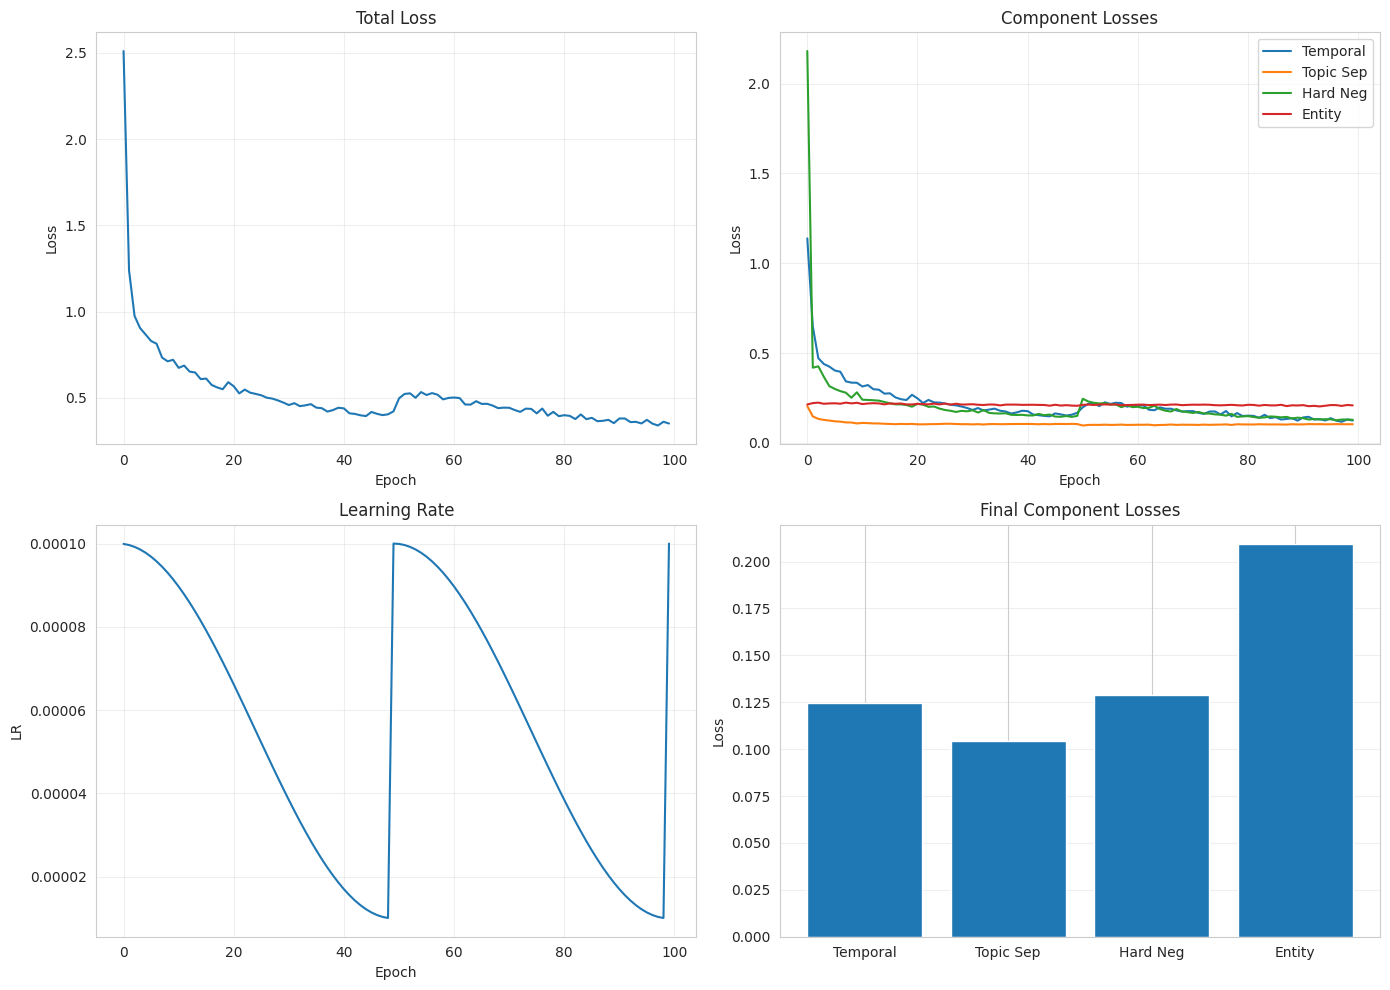

Training history plotted: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_train_loss.png


In [30]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(training_history['loss'])
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(training_history['temporal_loss'], label='Temporal')
axes[0, 1].plot(training_history['topic_sep_loss'], label='Topic Sep')
axes[0, 1].plot(training_history['hard_neg_loss'], label='Hard Neg')
if 'entity_loss' in training_history:
    axes[0, 1].plot(training_history['entity_loss'], label='Entity')
axes[0, 1].set_title('Component Losses')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(training_history['lr'])
axes[1, 0].set_title('Learning Rate')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('LR')
axes[1, 0].grid(True, alpha=0.3)

component_labels = ['Temporal', 'Topic Sep', 'Hard Neg']
component_values = [
    training_history['temporal_loss'][-1],
    training_history['topic_sep_loss'][-1],
    training_history['hard_neg_loss'][-1],
]
if 'entity_loss' in training_history:
    component_labels.append('Entity')
    component_values.append(training_history['entity_loss'][-1])

axes[1, 1].bar(component_labels, component_values)
axes[1, 1].set_title('Final Component Losses')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(config.TRAINING_HISTORY_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f'Training history plotted: {config.TRAINING_HISTORY_PLOT_PATH}')

## 8.5: AP4-Style Model Evaluation


Evaluation Metrics:
{
  "intra_scores": {
    "Health": 0.9428921114260228,
    "War": 0.9430488060467207,
    "Technology": 0.9405002045871025,
    "Climate": 0.9270038838362574,
    "Economics": 0.9383671154927968
  },
  "inter_scores": {
    "Health-War": -0.12831272913143038,
    "Health-Technology": -0.1350901377387345,
    "Health-Climate": -0.11918426487594842,
    "Health-Economics": -0.13040298648178578,
    "War-Technology": -0.13099819414317607,
    "War-Climate": -0.12302749797701835,
    "War-Economics": -0.12630575589835644,
    "Technology-Climate": -0.12675325041636826,
    "Technology-Economics": -0.13219170302152633,
    "Climate-Economics": -0.122595320250839
  },
  "separation_score": -7.360503456049188,
  "similarity_extremes": {
    "intra_min": 0.6794816255569458,
    "intra_max": 0.9997391700744629,
    "inter_min": -0.18681256473064423,
    "inter_max": 0.01835881546139717
  }
}

Similarity Extremes:
Intra -> min: 0.6794816255569458 | max: 0.9997391700744629 | 

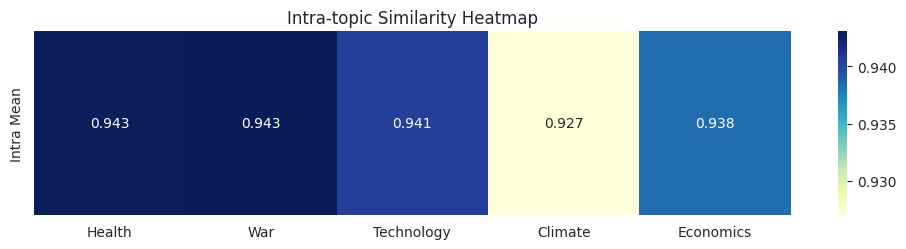

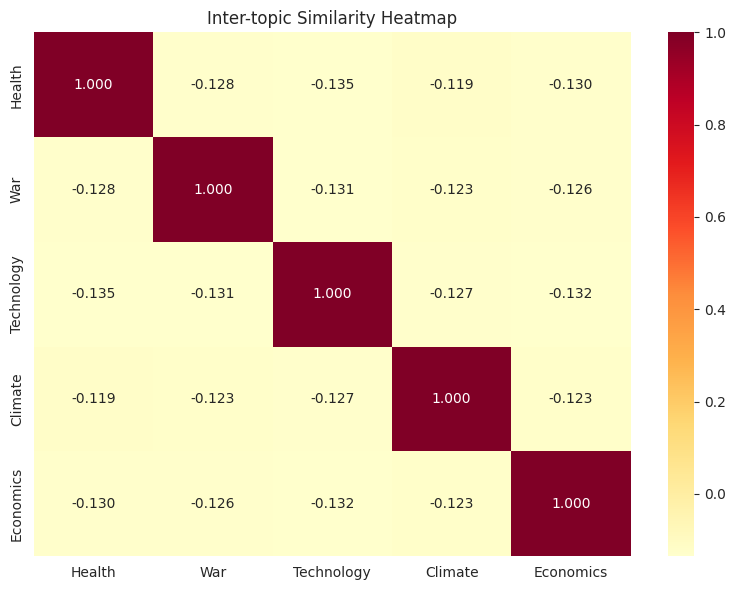

Saved evaluation metrics: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_evaluation_metrics.json
Saved evaluated model: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_evaluated.pt


In [31]:
def evaluate_model_quality(model, topic_window_data, config, device, per_topic_limit=200, inter_pairs=200, seed=42):
    model.eval()
    rng = np.random.default_rng(seed)
    topic_embeddings = {topic_name: [] for topic_name in config.TOPICS}

    with torch.no_grad():
        for topic_name in config.TOPICS:
            topic_payload = topic_window_data.get(topic_name, {})

            if isinstance(topic_payload, dict):
                windows = topic_payload.get("windows", [])
            else:
                windows = topic_payload

            if isinstance(windows, np.ndarray):
                windows = windows[:per_topic_limit]
            else:
                windows = list(windows)[:per_topic_limit]

            for window in windows:
                # Support both raw ndarray windows and dict-style payload windows.
                tensor_np = window.get("tensor") if isinstance(window, dict) else window
                if tensor_np is None:
                    continue

                tensor_np = np.asarray(tensor_np, dtype=np.float32)
                tensor = torch.from_numpy(tensor_np).unsqueeze(0).to(device)
                encoded = model(tensor).cpu().numpy()[0].astype(np.float32)
                topic_embeddings[topic_name].append(encoded)

            topic_embeddings[topic_name] = np.asarray(topic_embeddings[topic_name], dtype=np.float32)

    intra_scores = {}
    intra_pair_sims = {}
    for topic_name, embeddings in topic_embeddings.items():
        if len(embeddings) < 2:
            continue
        sims = []
        for i in range(len(embeddings) - 1):
            sims.append(float(np.dot(embeddings[i], embeddings[i + 1])))
        intra_pair_sims[topic_name] = sims
        intra_scores[topic_name] = float(np.mean(sims)) if sims else 0.0

    inter_scores = {}
    inter_pair_sims = {}
    topic_names = list(topic_embeddings.keys())
    for i in range(len(topic_names)):
        for j in range(i + 1, len(topic_names)):
            left_name, right_name = topic_names[i], topic_names[j]
            left = topic_embeddings[left_name]
            right = topic_embeddings[right_name]
            if len(left) == 0 or len(right) == 0:
                continue

            pairs = min(inter_pairs, len(left) * len(right))
            left_idx = rng.integers(0, len(left), size=pairs)
            right_idx = rng.integers(0, len(right), size=pairs)
            sims = [float(np.dot(left[li], right[ri])) for li, ri in zip(left_idx, right_idx)]

            pair_key = f"{left_name}-{right_name}"
            inter_pair_sims[pair_key] = sims
            inter_scores[pair_key] = float(np.mean(sims)) if sims else 0.0

    mean_intra = float(np.mean(list(intra_scores.values()))) if intra_scores else 0.0
    mean_inter = float(np.mean(list(inter_scores.values()))) if inter_scores else 0.0
    separation_score = mean_intra / (mean_inter + 1e-8) if mean_inter != 0 else 0.0

    intra_all = [v for values in intra_pair_sims.values() for v in values]
    inter_all = [v for values in inter_pair_sims.values() for v in values]

    similarity_extremes = {
        "intra_min": float(np.min(intra_all)) if intra_all else None,
        "intra_max": float(np.max(intra_all)) if intra_all else None,
        "inter_min": float(np.min(inter_all)) if inter_all else None,
        "inter_max": float(np.max(inter_all)) if inter_all else None,
    }

    return {
        "intra_scores": intra_scores,
        "inter_scores": inter_scores,
        "separation_score": separation_score,
        "similarity_extremes": similarity_extremes,
    }


def plot_evaluation_heatmaps(evaluation_metrics, config):
    topics = config.TOPICS
    intra_scores = evaluation_metrics.get("intra_scores", {})
    inter_scores = evaluation_metrics.get("inter_scores", {})

    intra_values = [float(intra_scores.get(topic, np.nan)) for topic in topics]
    intra_matrix = np.asarray(intra_values, dtype=np.float32).reshape(1, -1)

    inter_matrix = np.full((len(topics), len(topics)), np.nan, dtype=np.float32)
    for i, left in enumerate(topics):
        inter_matrix[i, i] = 1.0
        for j, right in enumerate(topics):
            if i >= j:
                continue
            key = f"{left}-{right}"
            if key not in inter_scores:
                key = f"{right}-{left}"
            if key in inter_scores:
                inter_matrix[i, j] = float(inter_scores[key])
                inter_matrix[j, i] = float(inter_scores[key])

    plt.figure(figsize=(10, 2.6))
    sns.heatmap(
        intra_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=topics,
        yticklabels=["Intra Mean"],
        cbar=True,
    )
    plt.title("Intra-topic Similarity Heatmap")
    plt.tight_layout()
    plt.savefig(config.OUTPUT_DIR / f"{config.MODEL_BASE_NAME}_eval_intra_heatmap.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        inter_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        xticklabels=topics,
        yticklabels=topics,
        cbar=True,
    )
    plt.title("Inter-topic Similarity Heatmap")
    plt.tight_layout()
    plt.savefig(config.OUTPUT_DIR / f"{config.MODEL_BASE_NAME}_eval_inter_heatmap.png", dpi=150)
    plt.show()


evaluation_metrics = evaluate_model_quality(model, topic_window_data, config, config.DEVICE)
print("Evaluation Metrics:")
print(json.dumps(evaluation_metrics, indent=2))

extremes = evaluation_metrics.get("similarity_extremes", {})
print("\nSimilarity Extremes:")
print(
    f"Intra -> min: {extremes.get('intra_min')} | max: {extremes.get('intra_max')} | "
    f"Inter -> min: {extremes.get('inter_min')} | max: {extremes.get('inter_max')}"
)

plot_evaluation_heatmaps(evaluation_metrics, config)

with open(config.EVAL_METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(evaluation_metrics, file, indent=2)

evaluated_checkpoint = {
    "model_state_dict": model.state_dict(),
    "evaluation_metrics": evaluation_metrics,
    "config": {
        "input_dim": config.CONCAT_DIM,
        "hidden_dim": config.HIDDEN_DIM,
        "output_dim": config.OUTPUT_DIM,
        "num_heads": config.NUM_HEADS,
        "num_layers": config.NUM_LAYERS,
        "dropout": config.DROPOUT,
    },
}
torch.save(evaluated_checkpoint, config.MODEL_EVALUATED_PATH)

print(f"Saved evaluation metrics: {config.EVAL_METRICS_PATH}")
print(f"Saved evaluated model: {config.MODEL_EVALUATED_PATH}")


## 9. Inference (User-level)


## 9.1: Load User Articles


In [70]:
def split_articles_into_sentences(input_dataframe):
    """AP4-style splitter: one row per sentence with stable sentence_id/article_id/date fields."""
    rows = []
    for article_idx, row in input_dataframe.reset_index(drop=True).iterrows():
        article_text = str(row.get("article", "")).strip()
        if not article_text:
            continue

        date_value = pd.to_datetime(row.get("date"), errors="coerce")
        if pd.isna(date_value):
            continue

        sentences = [s.text.strip() for s in nlp(article_text).sents if s.text and s.text.strip()]
        for sentence_order, sentence_text in enumerate(sentences):
            rows.append(
                {
                    "date": date_value,
                    "article_id": int(article_idx),
                    "sentence_id": f"a{int(article_idx)}_s{int(sentence_order)}",
                    "sentence_order": int(sentence_order),
                    "sentence_text": sentence_text,
                }
            )

    return pd.DataFrame(rows)


print("AP4 sentence splitter ready")


AP4 sentence splitter ready


## 9.2: Sentence Windowing


In [71]:
def build_context_texts(sentence_dataframe, context_window):
    if context_window not in (3, 5):
        raise ValueError("context_window must be 3 or 5")

    radius = context_window // 2
    radius=1
    sentence_dataframe = sentence_dataframe.sort_values(["article_id", "sentence_order"]).reset_index(drop=True).copy()
    context_texts = [""] * len(sentence_dataframe)

    for _, group in sentence_dataframe.groupby("article_id", sort=False):
        indices = group.index.tolist()
        sentences = group["sentence_text"].tolist()

        for local_idx, global_idx in enumerate(indices):
            left = max(0, local_idx - radius)
            right = min(len(sentences), local_idx + radius + 1)
            context_texts[global_idx] = " ".join(sentences[left:right])

    sentence_dataframe["context_text"] = context_texts
    return sentence_dataframe


def generate_contextual_sbert_embeddings(sentence_dataframe, config_dict, sbert_model_name="all-mpnet-base-v2"):
    model_sbert = SentenceTransformer(sbert_model_name, device="cpu")
    encoded = model_sbert.encode(
        sentence_dataframe["context_text"].tolist(),
        batch_size=int(config_dict["inference_batch_size"]),
        show_progress_bar=False,
        convert_to_numpy=True,
    )
    sentence_dataframe = sentence_dataframe.copy()
    sentence_dataframe["sentence_embeddings"] = [vec.astype(np.float32) for vec in np.asarray(encoded, dtype=np.float32)]
    return sentence_dataframe


def load_topic_embedding_prototypes(topic_embeddings_json_path, config_dict):
    with open(topic_embeddings_json_path, "r", encoding="utf-8") as file:
        payload = json.load(file)

    topic_embeddings = {}
    for topic_name in config_dict["topics"]:
        vector = np.asarray(payload[topic_name], dtype=np.float32)
        vector = vector / (np.linalg.norm(vector) + 1e-8)
        topic_embeddings[topic_name] = vector
    return topic_embeddings


def soft_topic_label_sentences(sentence_dataframe, topic_embeddings, config_dict):
    rows = []
    topic_names = config_dict["topics"]
    topic_matrix = np.stack([topic_embeddings[name] for name in topic_names]).astype(np.float32)
    topic_table_64 = np.asarray(config_dict["topic_embedding_table"], dtype=np.float32)

    for row in sentence_dataframe.itertuples(index=False):
        emb = np.asarray(row.sentence_embeddings, dtype=np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-8)

        similarities = np.dot(topic_matrix, emb).astype(np.float32)
        exp_sim = np.exp(similarities - np.max(similarities)).astype(np.float32)
        topic_probs = (exp_sim / (exp_sim.sum() + 1e-8)).astype(np.float32)

        topic_vec_64 = np.dot(topic_probs, topic_table_64).astype(np.float32)
        topic_vec_64 = topic_vec_64 / (np.linalg.norm(topic_vec_64) + 1e-8)

        record = {
            "date": row.date,
            "article_id": row.article_id,
            "sentence_id": row.sentence_id,
            "sentence_text": row.sentence_text,
            "sentence_order": int(row.sentence_order),
            "sentence_embeddings": emb.astype(np.float32),
            "topic_embeddings": topic_vec_64.astype(np.float32),
            "topic_probabilities": topic_probs.astype(np.float32),
        }
        for topic_idx, topic_name in enumerate(topic_names):
            record[topic_name] = np.float32(topic_probs[topic_idx])
        rows.append(record)

    return pd.DataFrame(rows)


def build_topic_score_rows(labeled_sentence_dataframe, config_dict):
    rows = []
    for row in labeled_sentence_dataframe.itertuples(index=False):
        for topic_name in config_dict["topics"]:
            rows.append({"sentence_id": row.sentence_id, "topic": topic_name, "similarity_score": float(getattr(row, topic_name))})
    return rows


print("AP4 context and soft-label helper functions ready")


AP4 context and soft-label helper functions ready


## 9.3: Compute Sentence Embeddings


In [72]:
def _normalize_topic_label(text):
    text = str(text).strip().lower()
    return "".join(ch for ch in text if ch.isalnum())


def resolve_topic_name(user_topic, config_topics):
    if user_topic in config_topics:
        return user_topic
    target = _normalize_topic_label(user_topic)
    for topic in config_topics:
        if target == _normalize_topic_label(topic):
            return topic
    raise ValueError(f"Unsupported topic '{user_topic}'. Choose one of: {config_topics}")


def compute_topic_similarity_with_embeddings(sentence_embeddings, topic_embedding):
    sentence_embeddings = np.asarray(sentence_embeddings, dtype=np.float32)
    topic_embedding = np.asarray(topic_embedding, dtype=np.float32)
    sentence_embeddings = sentence_embeddings / (np.linalg.norm(sentence_embeddings, axis=1, keepdims=True) + 1e-8)
    topic_embedding = topic_embedding / (np.linalg.norm(topic_embedding) + 1e-8)
    similarities = sentence_embeddings @ topic_embedding
    similarities = (similarities + 1.0) / 2.0
    return np.maximum(similarities, 0.3).astype(np.float32)


def compute_topic_drift(model, user_windows, config_dict, device):
    model.eval()
    if len(user_windows) < 2:
        return [], None

    with torch.no_grad():
        embeddings = []
        for window in user_windows:
            tensor = torch.from_numpy(window["tensor"]).unsqueeze(0).to(device)
            emb = model(tensor).cpu().numpy()[0].astype(np.float32)
            embeddings.append(emb)

    drift_rows = []
    for i in range(len(embeddings) - 1):
        drift_score = float(np.linalg.norm(embeddings[i + 1] - embeddings[i]))
        drift_rows.append(
            {
                "date": str(pd.Timestamp(user_windows[i + 1]["end_date"]).date()),
                "drift_score": drift_score,
                "window_idx": i,
                "topic_name": user_windows[i + 1]["topic_name"],
            }
        )
    return drift_rows, embeddings


def detect_shifts(drift_rows, config_dict):
    if not drift_rows:
        return []

    scores = np.asarray([row["drift_score"] for row in drift_rows], dtype=np.float32)
    mean_val = float(scores.mean())
    std_val = float(scores.std())
    std_val = std_val if std_val > 1e-8 else 1.0

    threshold = float(config_dict.get("manual_shift_threshold", 0.1))
    detected = []
    for row in drift_rows:
        z_score = float((row["drift_score"] - mean_val) / std_val)
        if row["drift_score"] >= threshold:
            item = dict(row)
            item["z_score"] = z_score
            detected.append(item)
    return detected


print("AP4 drift and shift helper functions ready")


AP4 drift and shift helper functions ready


## 9.4: Load Topic Embeddings (Ideal Articles)


In [73]:
def load_topic_embeddings_json(json_path):
    """
    Load ideal topic embeddings from JSON.
    
    Expected format:
    {
        "Health": [0.1, 0.2, ..., 0.768],
        "War": [...],
        ...
    }
    
    Returns:
        topic_embeddings: Dict of {topic_name: np.array(768,)}
    """
    print("\n" + "="*80)
    print("STEP 4: Loading topic embeddings (ideal articles)")
    print("="*80)
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    topic_embeddings = {
        topic: np.array(emb) for topic, emb in data.items()
    }
    
    print(f"✅ Loaded embeddings for topics: {list(topic_embeddings.keys())}")
    for topic, emb in topic_embeddings.items():
        print(f"   {topic}: {emb.shape}")
    
    return topic_embeddings

print("✅ Topic embedding loader defined")


✅ Topic embedding loader defined


## 9.5: Compute Topic Weights


In [74]:
from scipy.spatial.distance import cosine

def compute_topic_weights_inference(sentence_df, topic_embeddings):
    """
    Compute topic weights using cosine similarity.
    
    For each sentence, compute similarity to all 5 topic embeddings.
    
    Returns:
        sentence_df: DataFrame with topic weight columns added
    """
    print("\n" + "="*80)
    print("STEP 5: Computing topic weights (cosine similarity)")
    print("="*80)
    
    topics = list(topic_embeddings.keys())
    
    for topic in topics:
        topic_emb = topic_embeddings[topic]
        
        weights = []
        for sent_emb in tqdm(sentence_df['embedding'], desc=f"Computing {topic} weights"):
            # Cosine similarity = 1 - cosine distance
            sim = 1 - cosine(sent_emb, topic_emb)
            weights.append(max(0, sim))  # Clamp to [0, 1]
        
        sentence_df[f'{topic}_weight'] = weights
    
    print(f"✅ Topic weights computed for: {topics}")
    
    return sentence_df

print("✅ Topic weight computation defined")


✅ Topic weight computation defined


## 9.6: Filter by Topic Weight


In [75]:
def filter_by_topic_weights_inference(sentence_df, threshold=0.35):
    """
    Filter sentences where at least one topic weight > threshold.
    
    Returns:
        filtered_df: Filtered DataFrame
    """
    print("\n" + "="*80)
    print(f"STEP 6: Filtering sentences (topic weight > {threshold})")
    print("="*80)
    
    weight_cols = [col for col in sentence_df.columns if col.endswith('_weight')]
    
    # Keep if ANY topic weight > threshold
    mask = (sentence_df[weight_cols] > threshold).any(axis=1)
    
    filtered_df = sentence_df[mask].copy().reset_index(drop=True)
    
    print(f"✅ Filtered: {len(sentence_df)} → {len(filtered_df)} sentences")
    print(f"   Removed: {len(sentence_df) - len(filtered_df)} sentences below threshold")
    
    return filtered_df

print("✅ Filter function defined")


✅ Filter function defined


## 9.7: Entity-Invariant Cleaning


In [76]:
def extract_entities_inference(sentence_df, sbert_model, nlp):
    """
    Extract entities and compute 768D entity embeddings.
    """
    print("\n" + "=" * 80)
    print("STEP 7a: Extracting entities (NER)")
    print("=" * 80)

    all_entities = []
    entity_signatures = []
    entity_embeddings = []

    for sent in tqdm(sentence_df['center_sentence'], desc="Extracting entities"):
        doc = nlp(sent)
        entities = [ent.text.strip() for ent in doc.ents if ent.text and ent.text.strip()]
        all_entities.append(entities)

        if entities:
            normalized = sorted({e.lower() for e in entities})
            entity_signatures.append(" | ".join(normalized[:5]))
            ent_embs = sbert_model.encode(entities, convert_to_numpy=True).astype(np.float32)
            entity_emb = ent_embs.mean(axis=0).astype(np.float32)
        else:
            entity_signatures.append("__NO_ENTITY__")
            entity_emb = np.zeros(config.EMBEDDING_DIM, dtype=np.float32)

        norm = np.linalg.norm(entity_emb)
        if norm > 1e-6:
            entity_emb = entity_emb / norm

        entity_embeddings.append(entity_emb.astype(np.float32))

    sentence_df['entities'] = all_entities
    sentence_df['entity_signature'] = entity_signatures
    sentence_df['entity_embedding'] = entity_embeddings

    print("Entity embeddings computed")
    return sentence_df


def compute_clean_embeddings_inference(sentence_df, entity_proj_layer, device, lambda_=0.5):
    """
    Build inference dual representation:
      semantic_clean (768) + entity_small (64) -> final_embedding (832)
    """
    print("\n" + "=" * 80)
    print(f"STEP 7b: Entity-aware dual representation (lambda={lambda_})")
    print("=" * 80)

    semantic_clean = []
    entity_small = []
    final_embeddings = []

    entity_proj_layer.eval()

    for _, row in sentence_df.iterrows():
        sem_emb = np.asarray(row['embedding'], dtype=np.float32)
        ent_emb = np.asarray(row['entity_embedding'], dtype=np.float32)

        sem_clean = sem_emb - float(lambda_) * ent_emb
        sem_norm = np.linalg.norm(sem_clean)
        if sem_norm > 1e-6:
            sem_clean = sem_clean / sem_norm

        with torch.no_grad():
            ent_tensor = torch.from_numpy(ent_emb).to(device=device, dtype=torch.float32).unsqueeze(0)
            ent_small = entity_proj_layer(ent_tensor).squeeze(0).cpu().numpy().astype(np.float32)

        ent_small_norm = np.linalg.norm(ent_small)
        if ent_small_norm > 1e-6:
            ent_small = ent_small / ent_small_norm

        final_emb = np.concatenate([sem_clean.astype(np.float32), ent_small], axis=0).astype(np.float32)

        semantic_clean.append(sem_clean.astype(np.float32))
        entity_small.append(ent_small.astype(np.float32))
        final_embeddings.append(final_emb)

    sentence_df['semantic_clean_embedding'] = semantic_clean
    sentence_df['entity_small_embedding'] = entity_small
    sentence_df['final_embedding'] = final_embeddings

    print(f"Dual representation ready: {config.EMBEDDING_DIM} + {config.ENTITY_PROJ_DIM} = {config.SENTENCE_FINAL_DIM}")
    return sentence_df


print("Entity-aware inference functions defined")


Entity-aware inference functions defined


## 9.8: Day-Level Weighted Pooling


In [77]:
def aggregate_to_day_level_inference(sentence_df):
    """
    Aggregate sentence final embeddings (832D) to day-level per topic.

    Returns:
        day_df with embedding (832D) and entity_context per (date, topic)
    """
    print("\n" + "=" * 80)
    print("STEP 8: Day-level weighted pooling (per topic)")
    print("=" * 80)

    topics = ['Health', 'War', 'Technology', 'Climate', 'Economics']
    records = []

    for date, group in tqdm(sentence_df.groupby('date'), desc="Day aggregation"):
        for topic in topics:
            weight_col = f'{topic}_weight'
            if weight_col not in group.columns:
                continue

            embeddings = np.stack(group['final_embedding'].values).astype(np.float32)
            weights = group[weight_col].astype(np.float32).values

            weighted_sum = (embeddings.T * weights).T.sum(axis=0)
            weight_sum = weights.sum()

            if weight_sum > 0:
                day_embedding = weighted_sum / weight_sum
            else:
                day_embedding = embeddings.mean(axis=0)

            norm = np.linalg.norm(day_embedding)
            if norm > 1e-6:
                day_embedding = day_embedding / norm

            entity_set = sorted({str(x) for x in group.get('entity_signature', pd.Series([], dtype=str)).tolist() if str(x)})
            entity_context = " ; ".join(entity_set[:10]) if entity_set else "__NO_ENTITY__"

            records.append({
                'date': date,
                'topic': topic,
                'embedding': day_embedding.astype(np.float32),
                'num_sentences': len(group),
                'entity_context': entity_context,
            })

    day_df = pd.DataFrame(records)
    day_df = day_df.sort_values(['topic', 'date']).reset_index(drop=True)

    print("Day-level aggregation complete")
    print(f"  Total day-topic combinations: {len(day_df)}")
    print(f"  Days: {day_df['date'].nunique()}")
    print(f"  Topics: {day_df['topic'].nunique()}")

    return day_df


print("Day-level pooling function defined")


Day-level pooling function defined


## 9.9: Add Topic Embeddings


In [78]:
def add_topic_embeddings_inference(day_df, topic_emb_layer, topic_to_id, device):
    """
    Add learned topic embeddings to day embeddings.

    832D -> 896D (832 + 64)
    """
    print("\n" + "=" * 80)
    print("STEP 9: Adding learned topic embeddings (832D -> 896D)")
    print("=" * 80)

    embeddings_with_topic = []
    topic_emb_layer.eval()

    for _, row in day_df.iterrows():
        topic = row['topic']
        day_emb = np.asarray(row['embedding'], dtype=np.float32)

        topic_id = topic_to_id[topic]
        topic_emb = topic_emb_layer(torch.tensor([topic_id]).to(device)).detach().cpu().numpy()[0].astype(np.float32)

        combined_emb = np.concatenate([day_emb, topic_emb], axis=0).astype(np.float32)
        embeddings_with_topic.append(combined_emb)

    day_df['embedding_with_topic'] = embeddings_with_topic

    print("Topic embeddings added")
    print(f"  Shape: {config.SENTENCE_FINAL_DIM} + {config.TOPIC_EMB_DIM} = {config.CONCAT_DIM}")

    return day_df


print("Topic embedding addition function defined")


Topic embedding addition function defined


## 9.10: Create Day-Level Windows


In [79]:
def create_day_windows_inference(day_df, window_size=3):
    """
    Create windows from day-level embeddings (NO ruptures grouping).

    Returns:
        windows: (N, window_size, 896)
        window_metadata: topic/date/entity context per window
    """
    print("\n" + "=" * 80)
    print(f"STEP 10: Creating day-level windows (size={window_size}, NO grouping)")
    print("=" * 80)

    topics = day_df['topic'].unique()
    all_windows = []
    all_metadata = []

    for topic in topics:
        topic_df = day_df[day_df['topic'] == topic].sort_values('date').reset_index(drop=True)
        embeddings = np.stack(topic_df['embedding_with_topic'].values).astype(np.float32)

        for i in range(len(embeddings) - window_size + 1):
            window = embeddings[i:i + window_size]

            context_values = topic_df.iloc[i:i + window_size]['entity_context'].tolist() if 'entity_context' in topic_df.columns else []
            merged_context = " ; ".join([str(x) for x in context_values if str(x)])

            all_windows.append(window)
            all_metadata.append({
                'topic': topic,
                'start_date': topic_df.iloc[i]['date'],
                'end_date': topic_df.iloc[i + window_size - 1]['date'],
                'window_idx': i,
                'entity_context': merged_context if merged_context else '__NO_ENTITY__',
            })

    windows = np.array(all_windows)

    print(f"Windows created: {windows.shape}")
    print("  Per topic:")
    for topic in topics:
        topic_count = sum(1 for m in all_metadata if m['topic'] == topic)
        print(f"  - {topic}: {topic_count} windows")

    return windows, all_metadata


print("Day-level windowing function defined")


Day-level windowing function defined


## 9.11: Model Prediction


In [80]:
def predict_with_model_inference(windows, model, device, batch_size=32):
    """
    Run model forward pass on windows.
    
    Returns:
        embeddings: np.array of shape (N, 256)
    """
    print("\n" + "="*80)
    print("STEP 11: Model prediction")
    print("="*80)
    
    model.eval()
    
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(windows), batch_size), desc="Predicting"):
            batch = windows[i:i+batch_size]
            batch_tensor = torch.tensor(batch, dtype=torch.float32).to(device)
            
            embeddings = model(batch_tensor)
            
            all_embeddings.append(embeddings.cpu().numpy())
    
    embeddings = np.concatenate(all_embeddings, axis=0)
    
    print(f"✅ Predictions complete: {embeddings.shape}")
    
    return embeddings

print("✅ Model prediction function defined")


✅ Model prediction function defined


## 9.12: Day-Level Shift Detection


In [81]:
def detect_day_level_shifts_inference(embeddings, window_metadata, threshold_percentile=90, entity_overlap_threshold=0.2):
    """
    Detect narrative shifts with entity-aware filtering.

    Shift score: L2 distance between consecutive windows.
    Filter: ignore shift if entity overlap is below threshold.
    """
    print("\n" + "=" * 80)
    print("STEP 12: Day-level narrative shift detection")
    print("=" * 80)

    topics = list(set(m['topic'] for m in window_metadata))

    all_shifts = []
    all_shift_scores = []
    skipped_by_entity = 0

    for topic in topics:
        topic_indices = [i for i, m in enumerate(window_metadata) if m['topic'] == topic]
        topic_embeddings = embeddings[topic_indices]
        topic_metadata = [window_metadata[i] for i in topic_indices]

        shift_scores = []
        overlap_scores = []
        for i in range(len(topic_embeddings) - 1):
            dist = np.linalg.norm(topic_embeddings[i + 1] - topic_embeddings[i])
            shift_scores.append(float(dist))

            left_ctx = topic_metadata[i].get('entity_context', '__NO_ENTITY__')
            right_ctx = topic_metadata[i + 1].get('entity_context', '__NO_ENTITY__')
            overlap_scores.append(float(_jaccard_overlap_from_strings(left_ctx, right_ctx)))

        all_shift_scores.extend(shift_scores)

        if len(shift_scores) > 0:
            threshold = float(np.percentile(shift_scores, threshold_percentile))

            for i, score in enumerate(shift_scores):
                overlap = overlap_scores[i]
                if overlap < float(entity_overlap_threshold):
                    skipped_by_entity += 1
                    continue

                if score > threshold:
                    all_shifts.append({
                        'topic': topic,
                        'window_idx': i,
                        'start_date': topic_metadata[i]['start_date'],
                        'end_date': topic_metadata[i]['end_date'],
                        'next_start_date': topic_metadata[i + 1]['start_date'],
                        'shift_score': float(score),
                        'threshold': float(threshold),
                        'entity_overlap': float(overlap),
                        'entity_context': topic_metadata[i + 1].get('entity_context', '__NO_ENTITY__'),
                        'embedding_before': topic_embeddings[i],
                        'embedding_after': topic_embeddings[i + 1],
                    })

    print(f"Day-level shifts detected: {len(all_shifts)}")
    print(f"Skipped by entity-overlap filter: {skipped_by_entity}")
    if len(all_shift_scores) > 0:
        print(f"  Threshold (P{threshold_percentile}): {np.percentile(all_shift_scores, threshold_percentile):.4f}")

    return all_shifts, all_shift_scores


print("Day-level shift detection function defined")


Day-level shift detection function defined


## 9.13: Sentence-Level Shift Detection


In [82]:
def _to_int_article_id(article_id_value):
    text = str(article_id_value)
    digits = "".join(ch for ch in text if ch.isdigit())
    return int(digits) if digits else -1


def _build_sentence_context_string(row, source_df, context_window=2):
    article_rows = source_df[source_df["article_id"].astype(str) == str(row["article_id"])].copy()
    if article_rows.empty:
        return f">>> [{row['sentence_id']}] {row['sentence_text']}"

    article_rows = article_rows.sort_values("sentence_order").reset_index(drop=True)
    positions = article_rows.index[article_rows["sentence_id"].astype(str) == str(row["sentence_id"])].tolist()
    if not positions:
        return f">>> [{row['sentence_id']}] {row['sentence_text']}"

    pos = positions[0]
    start = max(0, pos - int(context_window))
    end = min(len(article_rows), pos + int(context_window) + 1)
    subset = article_rows.iloc[start:end]

    lines = []
    current_order = int(row["sentence_order"])
    for _, record in subset.iterrows():
        prefix = ">>> " if int(record["sentence_order"]) == current_order else "    "
        lines.append(f"{prefix}[{record['sentence_id']}] {record['sentence_text']}")
    return "\n".join(lines)


def extract_sentence_level_narrative_shifts(
    filtered_sentence_dataframe,
    drift_rows,
    config_dict,
    top_k_shifts=5,
    context_source_dataframe=None,
):
    detected_shifts = detect_shifts(drift_rows, config_dict)
    if filtered_sentence_dataframe.empty or not detected_shifts:
        return []

    filtered = filtered_sentence_dataframe.copy()
    filtered["date"] = pd.to_datetime(filtered["date"]).dt.normalize()

    if context_source_dataframe is None or context_source_dataframe.empty:
        context_source = filtered.copy()
    else:
        context_source = context_source_dataframe.copy()

    unique_dates = sorted(filtered["date"].unique())

    sentence_level_shifts = []
    ranked_shifts = sorted(detected_shifts, key=lambda x: x.get("z_score", 0.0), reverse=True)[: int(top_k_shifts)]

    for shift in ranked_shifts:
        date_2 = pd.Timestamp(shift["date"]).normalize()
        previous_dates = [d for d in unique_dates if d < date_2]
        if not previous_dates:
            continue
        date_1 = previous_dates[-1]

        sents_1 = filtered[filtered["date"] == date_1].sort_values("similarity_score", ascending=False).head(40)
        sents_2 = filtered[filtered["date"] == date_2].sort_values("similarity_score", ascending=False).head(40)
        if sents_1.empty or sents_2.empty:
            continue

        embs_1 = np.stack(sents_1["sentence_embeddings"].values).astype(np.float32)
        embs_2 = np.stack(sents_2["sentence_embeddings"].values).astype(np.float32)
        norm_1 = embs_1 / (np.linalg.norm(embs_1, axis=1, keepdims=True) + 1e-8)
        norm_2 = embs_2 / (np.linalg.norm(embs_2, axis=1, keepdims=True) + 1e-8)
        sims = np.dot(norm_1, norm_2.T).astype(np.float32)
        idx_1, idx_2 = np.unravel_index(int(np.argmin(sims)), sims.shape)

        sent1 = sents_1.reset_index(drop=True).iloc[idx_1]
        sent2 = sents_2.reset_index(drop=True).iloc[idx_2]
        min_similarity = float(sims[idx_1, idx_2])

        sentence_level_shifts.append(
            {
                "date_1": str(pd.Timestamp(date_1).date()),
                "date_2": str(pd.Timestamp(date_2).date()),
                "sentence_id_1": str(sent1["sentence_id"]),
                "article_id_1": _to_int_article_id(sent1["article_id"]),
                "sentence_num_1": int(sent1["sentence_order"]),
                "sentence_1": str(sent1["sentence_text"]),
                "topic_weight_1": float(sent1["similarity_score"]),
                "sentence_id_2": str(sent2["sentence_id"]),
                "article_id_2": _to_int_article_id(sent2["article_id"]),
                "sentence_num_2": int(sent2["sentence_order"]),
                "sentence_2": str(sent2["sentence_text"]),
                "topic_weight_2": float(sent2["similarity_score"]),
                "context_1": _build_sentence_context_string(sent1, context_source, context_window=2),
                "context_2": _build_sentence_context_string(sent2, context_source, context_window=2),
                "similarity": min_similarity,
                "shift_score": float(1.0 - min_similarity),
                "day_level_shift_score": float(shift.get("drift_score", 0.0)),
                "day_level_z_score": float(shift.get("z_score", 0.0)),
            }
        )

    return sentence_level_shifts


print("AP4 sentence-level shift helpers ready")

AP4 sentence-level shift helpers ready


## 9.14: Complete Inference Wrapper (Compatibility)


In [83]:
def _cfg_get(config_obj, key, default=None):
    if isinstance(config_obj, dict):
        return config_obj.get(key, default)
    return getattr(config_obj, key, default)


def get_user_inference_call_order():
    return [
        "1. split_articles_into_sentences",
        "2. build_context_texts",
        "3. generate_contextual_sbert_embeddings",
        "4. compute topic weights using ideal 768-d embeddings",
        "5. filter by topic threshold",
        "6. daily weighted pooling + add 64-d TCL topic embedding",
        "7. build temporal windows (adaptive if days < window_size)",
        "8. compute_topic_drift + detect_shifts",
        "9. sentence-level shift detection with context",
    ]


def add_temporal_features(group_dataframe):
    records = []
    rows = group_dataframe.sort_values("date").to_dict(orient="records")
    for row in rows:
        # 832-d pooled sentence vector + 64-d topic vector = 896-d model input vector.
        final_vector = np.concatenate([row["daily_vectors"], row["topic_embeddings"]]).astype(np.float32)
        records.append(
            {
                "date": row["date"],
                "end_date": row.get("end_date", row["date"]),
                "final_vector": final_vector,
                "topic_name": row["topic_name"],
                "topic_id": row["topic_id"],
            }
        )
    return records


def build_window_embeddings(enhanced_records, topic_name, topic_id, config_obj):
    enhanced_records = sorted(enhanced_records, key=lambda x: x["date"])
    window_size = int(_cfg_get(config_obj, "window_size", _cfg_get(config_obj, "WINDOW_SIZE", 3)))
    stride = int(_cfg_get(config_obj, "stride", _cfg_get(config_obj, "WINDOW_STRIDE", 1)))

    window_embeddings = []
    for start in range(0, len(enhanced_records) - window_size + 1, stride):
        chunk = enhanced_records[start:start + window_size]
        window_matrix = np.stack([item["final_vector"] for item in chunk]).astype(np.float32)
        window_embeddings.append(
            {
                "tensor": window_matrix,
                "topic_id": topic_id,
                "topic_name": topic_name,
                "start_date": chunk[0]["date"],
                "end_date": chunk[-1].get("end_date", chunk[-1]["date"]),
                "window_idx": start,
            }
        )
    return window_embeddings


def load_user_articles_csv(csv_path):
    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    return df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)


def process_articles_to_sentences(df):
    split_df = split_articles_into_sentences(df)
    split_df = build_context_texts(split_df, 5)
    split_df["center_sentence"] = split_df["sentence_text"]
    split_df["window_text"] = split_df["context_text"]
    return split_df


def compute_sentence_embeddings_inference(sentence_df, sbert_model):
    texts = sentence_df["window_text"].tolist()
    embeddings = sbert_model.encode(texts, batch_size=32, show_progress_bar=False, convert_to_numpy=True)
    out_df = sentence_df.copy()
    out_df["embedding"] = [vec.astype(np.float32) for vec in np.asarray(embeddings, dtype=np.float32)]
    return out_df


def detect_sentence_level_shifts_inference(day_shifts, sentence_df, model, topic_emb_layer, topic_to_id, device, top_k=5):
    _ = (day_shifts, sentence_df, model, topic_emb_layer, topic_to_id, device, top_k)
    return []


def build_inference_config(config_obj):
    return {
        "topics": list(config_obj.TOPICS),
        "context_window": 5,
        "embedding_dim": int(config_obj.EMBEDDING_DIM),
        "sentence_final_dim": int(config_obj.SENTENCE_FINAL_DIM),
        "topic_embedding_dim": int(config_obj.TOPIC_EMB_DIM),
        "concat_dim": int(config_obj.CONCAT_DIM),
        "topic_embedding_table": np.asarray(topic_emb_layer.weight.detach().cpu().numpy(), dtype=np.float32),
        "window_size": int(config_obj.WINDOW_SIZE),
        "stride": int(getattr(config_obj, "WINDOW_STRIDE", 1)),
        "temperature": float(config_obj.TEMPERATURE),
        "topic_threshold": 0.60,
        "topic_weight_threshold": 0.60,
        "manual_shift_threshold": float(config_obj.SHIFT_THRESHOLD),
        "inference_batch_size": 32,
    }


def run_user_level_inference(user_csv_path, model, config_dict, topic_name, ideal_topic_embeddings_json_path, sbert_model_name="all-mpnet-base-v2"):
    call_order = get_user_inference_call_order()
    resolved_topic = resolve_topic_name(topic_name, config_dict["topics"])
    input_dataframe = pd.read_csv(user_csv_path)
    sentence_dataframe = split_articles_into_sentences(input_dataframe)
    if sentence_dataframe.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": [],
            "training_like_rows": [],
        }

    sentence_dataframe = build_context_texts(sentence_dataframe, int(config_dict["context_window"]))
    sentence_dataframe = generate_contextual_sbert_embeddings(sentence_dataframe, config_dict, sbert_model_name=sbert_model_name)

    # Match training feature pipeline: contextual SBERT + entity-consistency cleaning -> final_embedding (832).
    sentence_dataframe["center_sentence"] = sentence_dataframe["sentence_text"]
    sentence_dataframe["embedding"] = sentence_dataframe["sentence_embeddings"]
    inference_sbert = SentenceTransformer(sbert_model_name, device="cpu")
    sentence_dataframe = extract_entities_inference(sentence_dataframe, inference_sbert, nlp)
    sentence_dataframe = compute_clean_embeddings_inference(
        sentence_dataframe,
        entity_proj_layer=entity_proj_layer,
        device=config.DEVICE,
        lambda_=config.ENTITY_LAMBDA,
    )

    ideal_embeddings = load_topic_embedding_prototypes(ideal_topic_embeddings_json_path, config_dict)
    labeled_sentence_dataframe = soft_topic_label_sentences(sentence_dataframe, ideal_embeddings, config_dict)

    # Preserve entity-aware features used by training (final_embedding) after soft-label helper reshaping.
    if "final_embedding" not in labeled_sentence_dataframe.columns and "final_embedding" in sentence_dataframe.columns:
        final_lookup = sentence_dataframe[["sentence_id", "final_embedding"]].drop_duplicates(subset=["sentence_id"]).copy()
        labeled_sentence_dataframe = labeled_sentence_dataframe.merge(final_lookup, on="sentence_id", how="left")

    if "final_embedding" not in labeled_sentence_dataframe.columns:
        raise KeyError("final_embedding missing after soft labeling. Re-run entity-cleaning cells before inference.")


    sentence_matrix = np.stack(labeled_sentence_dataframe["sentence_embeddings"].values).astype(np.float32)
    selected_topic_embedding = ideal_embeddings[resolved_topic]
    topic_weights = compute_topic_similarity_with_embeddings(sentence_matrix, selected_topic_embedding)

    labeled_sentence_dataframe = labeled_sentence_dataframe.copy()
    labeled_sentence_dataframe["similarity_score"] = topic_weights
    labeled_sentence_dataframe["selected_topic"] = resolved_topic

    topic_score_rows = build_topic_score_rows(labeled_sentence_dataframe, config_dict)

    threshold = float(config_dict.get("topic_threshold", config_dict.get("topic_weight_threshold", 0.60)))
    topic_weight_threshold = float(config_dict.get("topic_weight_threshold", threshold))

    topic_filtered_source = labeled_sentence_dataframe.copy()
    if resolved_topic in topic_filtered_source.columns:
        topic_filtered_source = topic_filtered_source[
            pd.to_numeric(topic_filtered_source[resolved_topic], errors="coerce").fillna(0.0).astype(np.float32) >= topic_weight_threshold
        ].copy()

    filtered_sentence_dataframe = topic_filtered_source[
        topic_filtered_source["similarity_score"].astype(np.float32) >= threshold
    ].copy().sort_values(["date", "article_id", "sentence_order"]).reset_index(drop=True)

    dedupe_keys = [col for col in ["date", "article_id", "sentence_id", "sentence_order"] if col in filtered_sentence_dataframe.columns]
    if dedupe_keys:
        filtered_sentence_dataframe = filtered_sentence_dataframe.drop_duplicates(subset=dedupe_keys, keep="first").reset_index(drop=True)

    if filtered_sentence_dataframe.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records"),
        }

    topic_id = int(config_dict["topics"].index(resolved_topic))
    topic_vec_64 = np.asarray(config_dict["topic_embedding_table"][topic_id], dtype=np.float32)

    expected_sentence_dim = int(config_dict.get("sentence_final_dim", 832))
    expected_topic_dim = int(config_dict.get("topic_embedding_dim", 64))
    expected_concat_dim = int(config_dict.get("concat_dim", expected_sentence_dim + expected_topic_dim))

    daily_rows = []
    grouped = filtered_sentence_dataframe.groupby(pd.to_datetime(filtered_sentence_dataframe["date"]).dt.normalize())
    for date_value, group in grouped:
        pooled_embeddings = np.stack(group["final_embedding"].values).astype(np.float32)
        if pooled_embeddings.shape[1] != expected_sentence_dim:
            raise ValueError(
                f"Inference sentence feature dim mismatch: got {pooled_embeddings.shape[1]}, expected {expected_sentence_dim}."
            )

        raw_weights = np.clip(group["similarity_score"].astype(np.float32).values, a_min=0.0, a_max=None)
        if raw_weights.sum() > 0:
            weights = raw_weights / raw_weights.sum()
        else:
            weights = np.ones(len(group), dtype=np.float32) / max(len(group), 1)

        daily_embedding = (pooled_embeddings.T @ weights).astype(np.float32)
        daily_embedding = daily_embedding / (np.linalg.norm(daily_embedding) + 1e-8)

        daily_rows.append(
            {
                "date": pd.Timestamp(date_value),
                "daily_vectors": daily_embedding,
                "topic_embeddings": topic_vec_64.copy(),
                "topic_name": resolved_topic,
                "topic_id": topic_id,
                "num_sentences": int(len(group)),
            }
        )

    user_daily_df = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)
    user_records = add_temporal_features(user_daily_df)

    if user_records:
        if topic_vec_64.shape[0] != expected_topic_dim:
            raise ValueError(
                f"Inference topic embedding dim mismatch: got {topic_vec_64.shape[0]}, expected {expected_topic_dim}."
            )
        if int(user_records[0]["final_vector"].shape[0]) != expected_concat_dim:
            raise ValueError(
                f"Inference concat dim mismatch: got {user_records[0]['final_vector'].shape[0]}, expected {expected_concat_dim}."
            )

    if len(user_records) < int(config_dict["window_size"]):
        user_windows = []
        for idx, record in enumerate(user_records):
            padded_tensor = np.stack([record["final_vector"]] * int(config_dict["window_size"])).astype(np.float32)
            user_windows.append(
                {
                    "tensor": padded_tensor,
                    "topic_id": topic_id,
                    "topic_name": resolved_topic,
                    "start_date": record["date"],
                    "end_date": record.get("end_date", record["date"]),
                    "window_idx": idx,
                }
            )
    else:
        user_windows = build_window_embeddings(user_records, resolved_topic, topic_id, config_dict)

    if user_windows:
        inferred_dim = int(user_windows[0]["tensor"].shape[-1])
        if inferred_dim != expected_concat_dim:
            raise ValueError(
                f"Window tensor feature dim mismatch: got {inferred_dim}, expected {expected_concat_dim}."
            )

        model_input_dim = None
        if hasattr(model, "input_projection") and hasattr(model.input_projection, "in_features"):
            model_input_dim = int(model.input_projection.in_features)
        elif hasattr(model, "input_linear") and hasattr(model.input_linear, "in_features"):
            model_input_dim = int(model.input_linear.in_features)
        if model_input_dim is not None and model_input_dim != inferred_dim:
            raise ValueError(
                f"Model input dim mismatch: model expects {model_input_dim}, inference windows have {inferred_dim}."
            )

    if len(user_windows) < 2:
        top_topic_sentences = (
            filtered_sentence_dataframe
            .sort_values("similarity_score", ascending=False)
            .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
            .to_dict(orient="records")
        )
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": top_topic_sentences,
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records"),
        }

    model_device = next(model.parameters()).device
    drift_rows, _ = compute_topic_drift(model, user_windows, config_dict, model_device)

    sentence_level_shifts = extract_sentence_level_narrative_shifts(
        filtered_sentence_dataframe=filtered_sentence_dataframe,
        drift_rows=drift_rows,
        config_dict=config_dict,
        top_k_shifts=5,
        context_source_dataframe=sentence_dataframe,
    )

    top_topic_sentences = (
        filtered_sentence_dataframe
        .sort_values("similarity_score", ascending=False)
        .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
        .to_dict(orient="records")
    )

    return {
        "call_order": call_order,
        "resolved_topic": resolved_topic,
        "sentence_level_narrative_shifts": sentence_level_shifts,
        "top_topic_sentences": top_topic_sentences,
        "topic_score_rows": topic_score_rows,
        "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records"),
    }


## 9.15: Example Inference Call


In [84]:
# Example inference call (load stored model, no need to re-run training)
user_csv_path = str(Path("/home/hp/SEM2/INLP/Naretve_Shift/Output/Model_Testing/Approch_4/Ner1_hard_combined.csv"))
ideal_topic_embeddings_json_path = "/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/topic_embeddings.json"

# Optional path to learned TCL 64-d topic embeddings from training artifacts.
default_tcl_topic_embeddings_path = config.OUTPUT_DIR / "topic_embeddings.json"
tcl_topic_embeddings_json_path = str(default_tcl_topic_embeddings_path) if default_tcl_topic_embeddings_path.exists() else None

# Enter one or many topics here. Example: ["War", "Health"] or list(config.TOPICS) for all.
selected_topics = list(config.TOPICS)
normalized_topics = [resolve_topic_name(topic, list(config.TOPICS)) for topic in selected_topics]
normalized_topics = list(dict.fromkeys(normalized_topics))

# -----------------------------
# Inference interface settings
# -----------------------------
inference_config = build_inference_config(config)
inference_config["topic_threshold"] = 0.45
inference_config["topic_weight_threshold"] = 0.20
inference_config["entity_overlap_threshold"] = 0.0
inference_config["shift_score_threshold_percentile"] = 10
inference_config["shift_threshold"]=0.3

inference_config["manual_shift_threshold"] = float(config.SHIFT_THRESHOLD)
inference_config["manual_shift_threshold"] = 0.3


# Select model variant to load from interface config: best | last | evaluated
inference_config["load_variant"] = "best"

checkpoint_map = {
    "best": config.MODEL_BEST_PATH,
    "last": config.MODEL_LAST_PATH,
    "evaluated": config.MODEL_EVALUATED_PATH,
}
checkpoint_path = checkpoint_map.get(inference_config["load_variant"], config.MODEL_BEST_PATH)

# Force inference to run on CPU
inference_device = torch.device("cpu")
device = inference_device

inference_model = TCLTemporalEncoder(config).to(inference_device)
checkpoint = torch.load(checkpoint_path, map_location=inference_device, weights_only=False)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
inference_model.load_state_dict(state_dict)
inference_model.eval()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

inference_results_by_topic = {}

print("Inference completed on CPU using stored checkpoint")
print(f"Model variant requested: {inference_config['load_variant']}")
print(f"Checkpoint loaded: {checkpoint_path}")
print(
    f"Config -> window_size={inference_config['window_size']} | "
    f"stride={inference_config.get('stride', 1)} | temperature={inference_config.get('temperature', config.TEMPERATURE)}"
)
print(
    f"Thresholds -> topic={inference_config['topic_threshold']} | "
    f"manual_shift={inference_config['manual_shift_threshold']}"
)
print(f"Topics to run: {normalized_topics}")

for selected_topic in normalized_topics:
    print("\n" + "#" * 120)
    print(f"TOPIC: {selected_topic}")
    print("#" * 120)

    result = run_user_level_inference(
        user_csv_path=user_csv_path,
        model=inference_model,
        config_dict=inference_config,
        topic_name=selected_topic,
        ideal_topic_embeddings_json_path=ideal_topic_embeddings_json_path,
        sbert_model_name="all-mpnet-base-v2",
    )
    inference_results_by_topic[selected_topic] = result

    print("Function call order:")
    for step in result["call_order"]:
        print(f"- {step}")

    print(f"Sentence-level narrative shifts: {len(result['sentence_level_narrative_shifts'])}")
    print("Detailed sentence-level output is printed in Section 12.")

# Keep backward-compatible single-topic variable using first topic result.
inference_result = inference_results_by_topic[normalized_topics[0]] if normalized_topics else {
    "call_order": [],
    "sentence_level_narrative_shifts": []
}

inference_output_payload = {
    "inference_metadata": {
        "load_variant": inference_config["load_variant"],
        "checkpoint_loaded": str(checkpoint_path),
        "thresholds": {
            "topic_threshold": inference_config.get("topic_threshold"),
            "manual_shift_threshold": inference_config.get("manual_shift_threshold"),
        },
    },
    "selected_topics": normalized_topics,
    "results_by_topic": inference_results_by_topic,
}

multi_topic_output_path = config.OUTPUT_DIR / f"{config.MODEL_BASE_NAME}_user_inference_multi_topic.json"
with open(multi_topic_output_path, "w", encoding="utf-8") as f:
    json.dump(inference_output_payload, f, indent=2, default=str)

print("\nSaved multi-topic inference output:")
print(multi_topic_output_path)


Inference completed on CPU using stored checkpoint
Model variant requested: best
Checkpoint loaded: tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_best.pt
Config -> window_size=3 | stride=1 | temperature=0.05
Thresholds -> topic=0.45 | manual_shift=0.3
Topics to run: ['Health', 'War', 'Technology', 'Climate', 'Economics']

########################################################################################################################
TOPIC: Health
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 523.18it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 737.98it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



STEP 7a: Extracting entities (NER)


Extracting entities: 100%|██████████| 61/61 [00:00<00:00, 69.80it/s]


Entity embeddings computed

STEP 7b: Entity-aware dual representation (lambda=0.3)
Dual representation ready: 768 + 64 = 832
Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 2
Detailed sentence-level output is printed in Section 12.

########################################################################################################################
TOPIC: War
########################################################################################################################


...

Entity embeddings computed

STEP 7b: Entity-aware dual representation (lambda=0.3)
Dual representation ready: 768 + 64 = 832
Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 3
Detailed sentence-level output is printed in Section 12.

########################################################################################################################
TOPIC: Economics
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 677.70it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1043.26it/s, Materializing param=pooler.dense.weight]                       
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



STEP 7a: Extracting entities (NER)


Extracting entities: 100%|██████████| 61/61 [00:01<00:00, 58.64it/s]


Entity embeddings computed

STEP 7b: Entity-aware dual representation (lambda=0.3)
Dual representation ready: 768 + 64 = 832
Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. compute topic weights using ideal 768-d embeddings
- 5. filter by topic threshold
- 6. daily weighted pooling + add 64-d TCL topic embedding
- 7. build temporal windows (adaptive if days < window_size)
- 8. compute_topic_drift + detect_shifts
- 9. sentence-level shift detection with context
Sentence-level narrative shifts: 5
Detailed sentence-level output is printed in Section 12.

Saved multi-topic inference output:
tcl_output_new_5/approch_entity_tcl_pen1_5_w3_s1_t0p05_user_inference_multi_topic.json


## 10. Utilities and Visualization


In [85]:
def print_shift_results(results, max_display=100):
    """
    Print narrative shift results in a readable format.
    """
    day_shifts = results['day_shifts']
    sentence_shifts = results['sentence_shifts']
    
    print("\n" + "="*80)
    print("DAY-LEVEL NARRATIVE SHIFTS")
    print("="*80)
    
    for i, shift in enumerate(day_shifts[:max_display]):
        print(f"\n[{i+1}] Topic: {shift['topic']}")
        print(f"    Date: {shift['start_date']} → {shift['next_start_date']}")
        print(f"    Shift Score: {shift['shift_score']:.4f} (threshold: {shift['threshold']:.4f})")
    
    if len(day_shifts) > max_display:
        print(f"\n... and {len(day_shifts) - max_display} more")
    
    print("\n" + "="*80)
    print("SENTENCE-LEVEL NARRATIVE SHIFTS")
    print("="*80)
    
    for i, shift in enumerate(sentence_shifts[:max_display]):
        print(f"\n[{i+1}] Topic: {shift['topic']} | Date: {shift['date']}")
        print(f"    Shift Contribution: {shift['shift_contribution']:.4f}")
        print(f"    Similarity Before: {shift['similarity_to_before']:.4f}")
        print(f"    Similarity After: {shift['similarity_to_after']:.4f}")
        print(f"    Day Shift Score: {shift['day_shift_score']:.4f}")
        print(f"\n    Sentence: \"{shift['sentence']}\"")
        
        if shift['context_before']:
            print(f"\n    Context Before:")
            for j, sent in enumerate(shift['context_before']):
                print(f"      [{j-len(shift['context_before'])}] {sent}")
        
        if shift['context_after']:
            print(f"\n    Context After:")
            for j, sent in enumerate(shift['context_after']):
                print(f"      [+{j+1}] {sent}")
    
    if len(sentence_shifts) > max_display:
        print(f"\n... and {len(sentence_shifts) - max_display} more")

def plot_shift_timeline(results, figsize=(14, 6)):
    """
    Plot shift scores timeline.
    """
    all_scores = results['all_shift_scores']
    day_shifts = results['day_shifts']
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Timeline
    ax1 = axes[0]
    x = np.arange(len(all_scores))
    ax1.plot(x, all_scores, linewidth=1, alpha=0.7)
    
    if len(all_scores) > 0:
        threshold = np.percentile(all_scores, 90)
        ax1.axhline(threshold, color='red', linestyle='--', label=f'P90 threshold')
    
    ax1.set_xlabel('Window Index')
    ax1.set_ylabel('Shift Score (L2 Distance)')
    ax1.set_title('Narrative Shift Timeline')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Distribution
    ax2 = axes[1]
    ax2.hist(all_scores, bins=30, alpha=0.7, edgecolor='black')
    
    if len(all_scores) > 0:
        threshold = np.percentile(all_scores, 90)
        ax2.axvline(threshold, color='red', linestyle='--', label=f'P90 threshold')
    
    ax2.set_xlabel('Shift Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Shift Score Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Summary:")
    print(f"   Total windows: {len(all_scores)}")
    print(f"   Significant shifts: {len(day_shifts)}")
    if len(all_scores) > 0:
        print(f"   Mean shift score: {np.mean(all_scores):.4f}")
        print(f"   Max shift score: {np.max(all_scores):.4f}")

print("✅ Visualization functions defined")




✅ Visualization functions defined


## 11. User Inference Sentence-Level Output (Final)

This stage is user-inference only. It prints final sentence-level narrative shift pairs with context and does not run training-side sentence-level detection.


In [86]:
# User-inference final print block (supports multi-topic results)
print("USER INFERENCE FINAL OUTPUT")
print("=" * 100)

if "inference_results_by_topic" in globals() and inference_results_by_topic:
    print(f"Topics in result: {list(inference_results_by_topic.keys())}")

    for topic_name, result in inference_results_by_topic.items():
        shifts = result.get("sentence_level_narrative_shifts", [])
        print("\n" + "#" * 100)
        print(f"TOPIC: {topic_name} | Total sentence-level shifts: {len(shifts)}")
        print("#" * 100)

        if len(shifts) == 0:
            print("No sentence-level shifts detected. Try lowering topic/zscore thresholds.")
            continue

        for i, shift in enumerate(shifts, 1):
            print(f"\nShift #{i}: {shift['date_1']} -> {shift['date_2']}")
            print(f"similarity={shift['similarity']:.4f} | shift_score={shift['shift_score']:.4f} | day_z={shift['day_level_z_score']:.4f}")
            print(f"\nDay 1 - {shift['sentence_id_1']} (Article {shift['article_id_1']}, Sentence {shift['sentence_num_1']})")
            print(f"topic_weight={shift['topic_weight_1']:.3f}")
            print(shift["context_1"])
            print(f"\nDay 2 - {shift['sentence_id_2']} (Article {shift['article_id_2']}, Sentence {shift['sentence_num_2']})")
            print(f"topic_weight={shift['topic_weight_2']:.3f}")
            print(shift["context_2"])
            print("-" * 100)
elif "inference_result" in globals():
    shifts = inference_result.get("sentence_level_narrative_shifts", [])
    print(f"Total sentence-level shifts: {len(shifts)}")

    if len(shifts) == 0:
        print("No sentence-level shifts detected. Try lowering topic/zscore thresholds.")
    else:
        for i, shift in enumerate(shifts, 1):
            print(f"\nShift #{i}: {shift['date_1']} -> {shift['date_2']}")
            print(f"similarity={shift['similarity']:.4f} | shift_score={shift['shift_score']:.4f} | day_z={shift['day_level_z_score']:.4f}")
            print(f"\nDay 1 - {shift['sentence_id_1']} (Article {shift['article_id_1']}, Sentence {shift['sentence_num_1']})")
            print(f"topic_weight={shift['topic_weight_1']:.3f}")
            print(shift["context_1"])
            print(f"\nDay 2 - {shift['sentence_id_2']} (Article {shift['article_id_2']}, Sentence {shift['sentence_num_2']})")
            print(f"topic_weight={shift['topic_weight_2']:.3f}")
            print(shift["context_2"])
            print("-" * 100)
else:
    print("Run the user inference call cell first.")


USER INFERENCE FINAL OUTPUT
Topics in result: ['Health', 'War', 'Technology', 'Climate', 'Economics']

####################################################################################################
TOPIC: Health | Total sentence-level shifts: 2
####################################################################################################

Shift #1: 2022-04-08 -> 2022-06-05
similarity=0.7782 | shift_score=0.2218 | day_z=0.8202

Day 1 - a2_s6 (Article 2, Sentence 6)
topic_weight=0.712
    [a2_s4] Lawmakers are beginning to debate the domestic implications of prolonged engagement.
    [a2_s5] The humanitarian situation continues to deteriorate.
>>> [a2_s6] Healthcare infrastructure in conflict zones is under severe strain, and access to basic services remains limited.
    [a2_s7] International agencies warn of long-term health consequences for displaced populations.
    [a2_s8] Energy experts note that while the crisis poses immediate challenges, it could also accelerate inves

## 12. Final Notes

All code logic and parameter values are preserved from `TCL_Pipeline_5.ipynb`.
